# 02 Data Cleaning

In [1729]:
import re
import pandas as pd
from bs4 import BeautifulSoup
import trafilatura
import matplotlib.pyplot as plt
import seaborn as sns
import html

In [1730]:
df = pd.read_parquet("../data/processed/articles_clean_notebook.parquet")

## 1. Field Quality: `full_text` vs `summary`

We have two text fields. Understanding their relationship helps decide which one to use downstream.

In [1731]:
# Compare lengths
df["full_text_len"] = df["full_text"].replace("", pd.NA).str.len()
df["summary_len"] = df["summary"].replace("", pd.NA).str.len()

stats = pd.concat(
    [
        df["full_text_len"].describe().round(0).rename("full_text"),
        df["summary_len"].describe().round(0).rename("summary"),
    ],
    axis=1,
)
print(stats.to_string())

       full_text  summary
count    24485.0  24413.0
mean      2589.0    821.0
std       3369.0   1357.0
min         95.0      4.0
25%       1162.0    123.0
50%       1830.0    507.0
75%       2899.0   1003.0
max      83416.0  31422.0


In [1732]:
# How often is full_text shorter than or equal to summary?
full_shorter = df[df["full_text_len"] <= df["summary_len"]]
print(
    f"Articles where full_text <= summary in length: {len(full_shorter)} ({len(full_shorter)/len(df)*100:.1f}%)"
)
print()
print(full_shorter[["source", "full_text_len", "summary_len"]].value_counts("source"))

Articles where full_text <= summary in length: 2498 (10.2%)

source
fakti      1678
24chasa     528
dnevnik     162
banker       82
bta          48
Name: count, dtype: int64


In [1733]:
for field in ["full_text", "summary"]:
    html_mask = df[field].fillna("").str.contains(r"<[a-zA-Z]", regex=True)
    print(f"=== {field.upper()} ===")
    print(f"Articles with HTML: {html_mask.sum()} ({html_mask.sum()/len(df)*100:.1f}%)")
    print("By source:")
    print(df[html_mask]["source"].value_counts().to_string())
    print()
    for source in df[html_mask]["source"].unique():
        sample = df[html_mask & (df["source"] == source)][field].iloc[0]
        print(f"--- {source} ---")
        print(sample[:400])
        print()
    print("=" * 60)
    print()

=== FULL_TEXT ===
Articles with HTML: 1 (0.0%)
By source:
source
monitor    1

--- monitor ---
"Ситуацията с Плана за възстановяване и устойчивост е критична. За петте години от началото на този eвропейски механизъм България е получила около 50% от парите - близо половината от които при кабинета "Донев". Останалите 50%, или близо 3 милиарда евро, трябва да бъдат спасени в следващите 3 месеца" - за това алармира вицепремиерът по европейски средства Атанас Пеканов в профила си във "Фейсбук".



=== SUMMARY ===
Articles with HTML: 11856 (48.4%)
By source:
source
24chasa    7020
fakti      4178
banker      403
dnevnik     255

--- 24chasa ---
<img alt="Ментор, лидер, баща… или просто Ханзи Флик!" height="600" src="https://cache2.24chasa.bg/Images/Cache/482/IMAGE_22838482_2_0.jpg" width="800" /> Германецът превърна съблекалнята в семейство и върна величието на &quot;Барселона&quot; чрез любов и дисциплина
Онази вечер той бе връхлетян от най-силната мъка, но няколко часа по-късно трябваше да

- full_text is on average 3.4× longer than summary, confirming it as the primary field for embedding and retrieval.
- ~50% of summaries contain raw HTML tags — stripping is required before any use.
- ~10% of articles have full_text ≤ summary length, concentrated in fakti (likely HTML inflation) and 24chasa/dnevnik (possibly truncated full text).

### 1a. HTML striping from `summary`

In [1734]:
def strip_html(text):
    if not isinstance(text, str):
        return ""
    return BeautifulSoup(text, "html.parser").get_text(separator=" ", strip=True)

In [1735]:
def print_by_words(text, chunk=20):
    words = text.split()
    for i in range(0, len(words), chunk):
        print(" ".join(words[i : i + chunk]))

In [1736]:
for _, row in df[df["summary"].str.len() > 0].sample(3, random_state=42).iterrows():
    print(f"source: {row['source']}")
    print_by_words(row["summary"])
    print()

source: 24chasa
<img alt="Вижте най-забележителните визии на &quot;Мет Гала&quot; тази година (Снимки)" height="600" src="https://cache2.24chasa.bg/Images/Cache/566/IMAGE_22786566_2_0.jpg" width="800" /> На 4 май бе най-голямата вечер
в света на модата - &quot;Мет Гала&quot; 2026. Тазгодишната тема бе &quot;Изкуството на костюма&quot; и организаторите приканиха звездите да експериментират
с дрескода. Годишното събитие е благотворителна акция за набиране на средства за Института за костюми към Музея „Метрополитън&quot; и предоставя
възможност на знаменитостите и модните

source: nova
Имало ли е контрол и кой носи отговорност

source: fakti
<img src="https://cdn4.focus.bg/fakti/photos/big/bd3/isw-rusia-prodaljava-masiranite-udari-sreshtu-ukraina-predi-latnata-ofanziva-1.webp" /><p>Руските сили извършиха масиран удар с дронове и ракети срещу Украйна в нощта на 24 срещу 25 април.
Ударът бе насочен предимно към град Днепър, Днепропетровска област. Убити са най-малко шест цивилни и ранени на

In [1737]:
df["summary"] = df["summary"].apply(strip_html)

In [1738]:
for _, row in df[df["summary"].str.len() > 0].sample(3).iterrows():
    print(f"source: {row['source']}")
    print_by_words(row["summary"])
    print()

source: monitor
ЦСКА стана на 78! Вижте какво написаха "армейците" за рождения си ден

source: fakti
Легендата на кънтри музиката Доли Партън отново отложи поредица от планирани концерти в Лас Вегас по здравословни причини , след
като през последните месеци неколкократно преразглежда графика си заради продължаващо лечение. Информацията беше потвърдена от самата изпълнителка чрез официалните ѝ
канали. 80-годишната носителка на множество награди, сред които и отличия от Грами, съобщи още през есента на миналата година, че
отлага част от участията си. Решението предизвика спекулации относно състоянието ѝ, допълнително засилени от публичен апел на нейна сестра за
подкрепа от феновете. В отговор Доли публикува видео, в което увери, че състоянието ѝ се подобрява и че остава активна
професионално. Вижте тази публикация в Instagram. Публикация, споделена от Dolly Parton (@dollyparton) В последното си изявление певицата уточнява, че възстановяването
протича по план, но лечението все още оказва 

In [1739]:
for field in ["summary"]:
    html_mask = df[field].fillna("").str.contains(r"<[a-zA-Z]", regex=True)
    print(f"=== {field.upper()} ===")
    print(f"Articles with HTML: {html_mask.sum()} ({html_mask.sum()/len(df)*100:.1f}%)")
    print("By source:")
    print(df[html_mask]["source"].value_counts().to_string())
    print()
    for source in df[html_mask]["source"].unique():
        sample = df[html_mask & (df["source"] == source)][field].iloc[0]
        print(f"--- {source} ---")
        print_by_words(sample)
        print()
    print("=" * 60)
    print()

=== SUMMARY ===
Articles with HTML: 141 (0.6%)
By source:
source
fakti    141

--- fakti ---
Вълнуваща история с щастлив край развълнува феновете на колоезденето у нас по време на Джиро д’Италия 2026. Деси и Йосиф,
по-известни сред зрителите като "динозаврите" заради своите забавни и ярки костюми, се превърнаха в истински любимци на публиката още от
първите етапи на състезанието в България. Докато вълната от ентусиазъм и емоции заливаше трасето между София и Боровец, двойката преживя
истинска драма – брачната халка на Йосиф мистериозно изчезна по време на изкачването. С надежда за чудо, Деси и Йосиф
отправиха апел към всички присъстващи и онлайн общността: всеки, който разполага със снимки или видеа от маршрута, да помогне в
издирването на безценния пръстен. Вълната от съпричастност не закъсня. Организаторите на Джиро д’Италия, медии и стотици фенове се включиха в
издирването, преглеждайки кадри и претърсвайки района. Първоначално надеждите изглеждаха напразни, но упоритостта и колекти

## Decision: Drop `summary`

The `summary` field is sourced directly from the RSS `<description>` tag and is inconsistent across sources — some articles have a meaningful short intro, others have a duplicate of `full_text`, and roughly 50% contain raw HTML markup. Several sources (`vesti`, `segabg`) provide no summary at all.

Since `full_text` is the authoritative text field used for all downstream tasks `summary` adds no value and is dropped.


In [1740]:
df = df.drop(columns=["summary", "full_text_len", "summary_len"])

In [1741]:
df.head(3)

,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count
0,monitor,БРУТАЛЕН УЛИЧЕН ЕКШЪН! Ивайло Мирчев нападнат ...,https://telegraph.bg/bulgaria/novini/brutalen-...,2026-05-16T03:25:57.118441+00:00,Н ародният представител и съпредседател на ДБ ...,2026-05-16T03:25:57.118444+00:00,2026-05-16 03:25:57.118441+00:00,309
1,monitor,ВОЙНАТА В УКРАЙНА: Правят трибунал за преследв...,https://telegraph.bg/svetat/novini/vojnata-v-u...,2026-05-16T03:25:57.118434+00:00,"Т ридесет и шест държави, основно от Европа, с...",2026-05-16T03:25:57.118436+00:00,2026-05-16 03:25:57.118434+00:00,747
2,monitor,Инински: В София ще поставим началото на новит...,https://telegraph.bg/sport/oshte-sport/ininski...,2026-05-16T03:25:57.118427+00:00,До началото на Европейското първенство по бокс...,2026-05-16T03:25:57.118429+00:00,2026-05-16 03:25:57.118427+00:00,631


## 2. Cyrillic & Encoding Quality Check

Bulgarian uses the Cyrillic alphabet. Encoding issues (e.g. Windows-1251 misread as UTF-8) produce garbled text.
We check how much of the text is valid Cyrillic and flag suspicious articles.

In [1742]:
def is_mojibake(text: str) -> bool:
    if not isinstance(text, str) or not text.strip():
        return False
    dash_ratio = (text.count("–") + text.count("—")) / max(len(text), 1)
    return dash_ratio > 0.05

In [1743]:
mojibake_mask = df["full_text"].apply(is_mojibake)
print(
    f"Unreadable (mojibake): {mojibake_mask.sum()} ({mojibake_mask.sum()/len(df)*100:.1f}%)"
)
print(df[mojibake_mask]["source"].value_counts().to_string())
print()

Unreadable (mojibake): 24 (0.1%)
source
actualno    24



In [1744]:
for _, row in df[mojibake_mask][["source", "title", "full_text"]].head(3).iterrows():
    print(f"  Source : {row['source']}")
    print(f"  Title  : {row['title']}")
    print(f"  Preview: {row['full_text'][:200]}")
    print()

  Source : actualno
  Title  : Астън Вила разби Ливърпул в 6-голово шоу и си осигури място в Шампионска лига
  Preview: –Р—Б—В—К–љ –Т–Є–ї–∞ —А–∞–Ј–≥—А–Њ–Љ–Є –Ы–Є–≤—К—А–њ—Г–ї —Б 4:2 –Є —Б–Є –Њ—Б–Є–≥—Г—А–Є –Ї–ї–∞—Б–Є—А–∞–љ–µ –Ј–∞ –®–∞–Љ–њ–Є–Њ–љ—Б–Ї–∞—В–∞ –ї–Є–≥–∞. –Т –і–≤—Г–±–Њ–є –Њ—В 37-–Є—П –Ї—А—К–≥ –љ–∞ –Т–Є—Б—И–∞—В–∞

  Source : actualno
  Title  : Легендата пренаписа историята: Сър Дейвид Бекъм е първият британски спортист милиардер!
  Preview: –С–Є–≤—И–∞—В–∞ –Є–Ї–Њ–љ–∞ –љ–∞ –∞–љ–≥–ї–Є–є—Б–Ї–Є—П —Д—Г—В–±–Њ–ї –Ф–µ–є–≤–Є–і –С–µ–Ї—К–Љ –Њ—Д–Є—Ж–Є–∞–ї–љ–Њ –њ—А–µ–љ–∞–њ–Є—Б–∞ –Є—Б—В–Њ—А–Є—П—В–∞, –њ—А–µ–≤—А—К—Й–∞–є–Ї–Є —Б–µ –≤ –њ—К—А–≤–Є—П –±—А–Є—В–

  Source : actualno
  Title  : Много жертви и ранени, поразени сгради и атака срещу ООН: Разрухата след поредното руско зверство в Украйна (ВИДЕО)
  Preview: –Э–∞–є-–Љ–∞–ї–Ї–Њ –њ–µ—В–Є–Љ–∞ –і—Г—И–Є —Б–∞ –Ј–∞–≥–Є–љ–∞–ї–Є –≤ –Ъ–Є–µ–≤ –≤ —А–µ–Ј—Г–ї—В–∞—В –љ–∞ —А—Г—Б–Ї–∞—В–∞ –∞—В–∞–Ї–∞ –Њ—В —Б–љ–Њ—Й–Є, 13 —Б—А–µ—Й—Г 14 –Љ–∞–є. –Ю–Ї–Њ–ї–Њ 40 –і—Г—И–

In [1745]:
df = df[~mojibake_mask].reset_index(drop=True)
print(f"Dropped {mojibake_mask.sum()} unreadable articles. Remaining: {len(df)}")

Dropped 24 unreadable articles. Remaining: 24461


**Finding:** A small number of articles from `actualno` contained fully unreadable text — classic mojibake produced by Windows-1251 content misread as UTF-8, recognisable by an abnormally high density of `–`/`—` characters.

**Decision:** Dropped all articles where more than 5% of characters are em/en dashes. All remaining articles contain readable Bulgarian text.


## 3. Source-Specific Investigations

### 3a. Dnevnik — JavaScript-Rendered Content

In [1746]:
if "dnevnik" in df["source"].values:
    dnevnik_sample = df[df["source"] == "dnevnik"][
        ["title", "url", "word_count", "full_text"]
    ].sort_values("word_count")
    print(f"Total dnevnik articles : {len(dnevnik_sample)}")
    print(f"Median word count      : {dnevnik_sample['word_count'].median()}")
    print()
    for _, row in dnevnik_sample.head(3).iterrows():
        print(f"Title   : {row['title']}")
        print(f"Words   : {row['word_count']}")
        print(f"Full text : {row['full_text'][:300]}")
        print("-" * 60)

Total dnevnik articles : 255
Median word count      : 23.0

Title   : Слънчево и топло време в събота
Words   : 13
Full text : 06:20Слънчево и топло време в съботаДневник0СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber25 април 2026
------------------------------------------------------------
Title   : САЩ разхлабват правилата за канабиса
Words   : 14
Full text : 21:30САЩ разхлабват правилата за канабисаДневник5СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber23 април 2026ВСИЧКИ БЪРЗИ НОВИНИ
------------------------------------------------------------
Title   : "Левски" има нов собственик
Words   : 14
Full text : HomeСпорт"Левски" има нов собственикЦВЕТЕЛИНА БЕЛУТОВААтанас БостанджиевАндриян Георгиев37СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber24 април 2026
------------------------------------------------------------


In [1747]:
# Verify with trafilatura directly
if "dnevnik" in df["source"].values:
    test_url = df[df["source"] == "dnevnik"]["url"].iloc[0]
    downloaded = trafilatura.fetch_url(test_url)
    result = trafilatura.extract(downloaded) if downloaded else None
    print(
        f"Trafilatura extraction result: {repr(result[:200]) if result else 'None — extraction failed'}"
    )

Trafilatura extraction result: 'HomeСвятПреговорите САЩ-Иран в Пакистан приключиха преди да започнат, Тръмп ги прекъснаReutersПетър Карабоев97СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber25 април 2026Удар'


**Finding:** Dnevnik runs on Next.js. Trafilatura receives the bare HTML shell before JavaScript renders the content.
All 253 articles contain only 13–14 words of boilerplate (timestamps, share buttons).

**Decision:** Remove Dnevnik from the dataset.

In [1748]:
mask = df["source"] == "dnevnik"

print(f"Dropping {mask.sum()} articles from: dnevnik")
df = df[~mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 255 articles from: dnevnik
Remaining articles: 24206


### 3b. 24chasa — Very Long Outliers

In [1749]:
chasa_outliers = df[(df["source"] == "24chasa") & (df["word_count"] > 3000)][
    ["title", "url", "word_count", "full_text"]
].sort_values("word_count", ascending=False)

print(f"24chasa articles over 3000 words: {len(chasa_outliers)}")
print()
for _, row in chasa_outliers.head(5).iterrows():
    print(f"Title   : {row['title']}")
    print(f"Words   : {row['word_count']}")
    print(f"Preview : {row['full_text'][:300]}")
    print("-" * 60)

24chasa articles over 3000 words: 28

Title   : Вижте какво е състоянието на пътищата тази вечер
Words   : 13773
Preview : Агенция "Пътна инфраструктура" информира за състоянието на пътищата, въведените ограничения и метеорологичната обстановка у нас към 17:30 часа.
I. МЕТЕОРОЛОГИЧНА ОБСТАНОВКА:
През следващото денонощие синоптичната обстановка в страната ще бъде усложнена. Ще бъде облачно и с повсеместни валежи от дъжд
------------------------------------------------------------
Title   : Вижте какво е състоянието на пътищата тази вечер
Words   : 13275
Preview : Агенция "Пътна инфраструктура" информира за състоянието на пътищата, въведените ограничения и метеорологичната обстановка у нас към 17:30 часа.
I. МЕТЕОРОЛОГИЧНА ОБСТАНОВКА:
През нощта ще преобладава ясно време с по-значителна облачност над Западна България, но само на отделни места ще превалява дъж
------------------------------------------------------------
Title   : Вижте какво е състоянието на пътищата тази вечер
Words   :

In [1750]:
short_24chasa = df[(df["source"] == "24chasa") & (df["word_count"] < 50)]
print(f"24chasa articles under 50 words: {len(short_24chasa)}")
print(short_24chasa[["title", "word_count", "full_text"]].to_string())

24chasa articles under 50 words: 85
                                                                                                          title  word_count                                                                                                                                                                                                                                                                                                                                                              full_text
69                                                                                    На 16 май рожден ден имат          45                           Григор Димитров, тенисист\nВладимир Житенски, председател на борда на директорите и изпълнителен директор на "Джи Пи Груп" АД\nИнж. Стефан Чайков, председател на УС на Българска браншова камара "Пътища"\nДани Милев, музикант\nЕрол, вокалист на "Уикеда"\nАлбена Ставрева, актриса\nСтанислав Яневски, актьор\nИвелин Николов, журналис

**Finding:** 24chasa — Two edge cases

Very short articles (< 50 words): 

Inspection shows two patterns:

- Pure boilerplate stubs — newsletter prompts, social links, no real content (e.g. "24 часа в мейла ти...")
- Legitimate short-form content — breaking news flashes, traffic updates, photo captions (37–49 words)

Very long articles (> 3 000 words):
All are structured road condition reports published daily by the Road Infrastructure Agency under the same title ("Вижте какво е състоянието на пътищата тази вечер"), reaching up to 13 773 words. These are not news articles and would pollute RAG retrieval.

### 3c. Per-Source Shortest & Longest Articles

In [1751]:
for source in df["source"].unique():
    source_df = df[df["source"] == source].sort_values("word_count")
    print(f"=== {source.upper()} ===")
    print(
        f"Total: {len(source_df)} | Median words: {source_df['word_count'].median():.0f}"
    )
    print()
    print("-- 2 SHORTEST --")
    for _, row in source_df.head(2).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  Preview: {row['full_text'][:150]}")
        print()
    print("-- 2 LONGEST --")
    for _, row in source_df.tail(2).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  Preview: {row['full_text'][:150]}")
        print()
    print("=" * 60)
    print()

=== MONITOR ===
Total: 1096 | Median words: 222

-- 2 SHORTEST --
  [35 words] Румънското правителство падна!
  Preview: Р умънският парламент подкрепи вота на недоверие срещу Илие Боложан.
Той беше внесен от социалдемократите и крайната десница.
Решението задълбочава по

  [39 words] ЦСКА със специален поздрав към феновете
  Preview: Ф утболистите, треньорите и част от ръководството поздравиха феновете на тима по случай 78-годишнина, която клубът празнува днес.
Христо Янев и компан

-- 2 LONGEST --
  [2790 words] Експертът по въздействие на атмосферата Стефан Бабов пред “Телеграф”: В САЩ викат АI на помощ за повече дъжд
  Preview: - Г-н Бабов, преди дни се върнахте от САЩ, където бяхте единственият българин на конгреса на Световната асоциация за изкуствени въздействия в атмосфер

  [3173 words] Доц. Людмила Беленска: Невежеството е най-опасно за здравето
  Preview: - Развитието на технологиите и конкретно AI с какво промениха генетиката и кое може да определим като най-модерното в таз

### 3d. Calculator Articles

In [1752]:
calculator_articles = df[
    (df["source"] == "actualno")
    & (df["title"].str.contains("валутен калкулатор", na=False))
]

print(f"Calculator articles: {len(calculator_articles)}")
print(calculator_articles[["title", "word_count", "url"]].to_string())

Calculator articles: 104
                                                                                                     title  word_count                                                                                                                                               url
95                                Евро - лев. Калкулатор от евро в стария лев, 16 май /валутен калкулатор/          66                            https://www.actualno.com/finance/evro-lev-kalkulator-ot-evro-v-starija-lev-16-maj-valuten-kalkulator-news_2594882.html
96       Турска лира - евро. Колко струва една турска лира към едно евро днес, 16 май /валутен калкулатор/         226    https://www.actualno.com/finance/turska-lira-evro-kolko-struva-edna-turska-lira-kym-edno-evro-dnes-16-maj-valuten-kalkulator-news_2594879.html
97            Долар - евро. Колко струва един щатски долар към едно евро днес, 16 май /валутен калкулатор/          66       https://www.actualno.com/finance/dolar-evro-kolko-struv

In [1753]:
road_mask = (df["source"] == "24chasa") & (
    df["title"].str.contains("състоянието на пътищата", na=False)
)
print(f"Road condition reports: {road_mask.sum()}")

calc_mask = (df["source"] == "actualno") & (
    df["title"].str.contains("валутен калкулатор", na=False)
)
print(f"Calculator articles: {calc_mask.sum()}")

short_mask = df["word_count"] < 30
print(f"Articles under 30 words: {short_mask.sum()}")

Road condition reports: 20
Calculator articles: 104
Articles under 30 words: 20


**Decision:** drop records with following content:
- Boilerplate stubs (< 30 words, 24chasa) — newsletter prompts and social share links with no real content.
- Daily currency calculators (actualno) — four currency pairs published as articles every day, identified by "калкулатор" in the title.
- Road condition reports (24chasa) — daily government bulletins up to 13 773 words, identified by "състоянието на пътищата" in the title.

In [1754]:
print(f"Dropping {short_mask.sum()} articles under 30 words")
df = df[~short_mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 20 articles under 30 words
Remaining articles: 24186


In [1755]:
mask = (df["source"] == "24chasa") & (
    df["title"].str.contains("състоянието на пътищата", na=False)
)
print(f"Dropping {mask.sum()} road condition reports")
df = df[~mask].reset_index(drop=True)

mask = (df["source"] == "actualno") & (
    df["title"].str.contains("валутен калкулатор", na=False)
)
print(f"Dropping {mask.sum()} calculator articles")
df = df[~mask].reset_index(drop=True)

print(f"Remaining: {len(df)}")

Dropping 20 road condition reports
Dropping 104 calculator articles
Remaining: 24062


### 3e. Fakti outliers

In [1756]:
fakti_outliers = df[(df["source"] == "fakti") & (df["word_count"] > 2000)].sort_values(
    "word_count", ascending=False
)

print(f"Fakti articles over 2000 words: {len(fakti_outliers)}")
print()
for _, row in fakti_outliers.head(5).iterrows():
    print(f"Title   : {row['title']}")
    print(f"Words   : {row['word_count']}")
    print(f"Preview : {row['full_text'][:400]}")
    print(f"End     : {row['full_text'][-400:]}")
    print("-" * 60)

Fakti articles over 2000 words: 148

Title   : В Москва! Парадът на победата на Червения площад (ВИДЕО)
Words   : 10868
Preview : Парадът в чест на 81-вата годишнина от победата във Великата отечествена война започна на Червения площад, съобщи ТАСС, цитирана от БТА.
Началото му бе отбелязано с ударите на курантите на Спаската кула. Под оркестровото изпълнение на легендарната композиция "Свещената война" на паветата на Червения площад бяха изнесени държавният флаг на Руската федерация и флагът на Съветския съюз, страната побе
End     : оленето и истината винаги се разминават. Не, че това има значение за безроден глупак!
13:57 09.05.2026
390 Северно Корейския ХОБИТ
До коментар #119 от "Мунчо":
Пратил малко РобиДа ги нагостят със
КУЧЕШКО ВАРЕНО
В Северна Корея
Сабаки нетъ.
13:57 09.05.2026
391 Така е
До коментар #386 от "Себе си описа,":
Безродника няма родина и затова клоака като запада го ползва за евтин отпадък!13:58 09.05.2026
----------------------------------------------------------

**Finding:** The long outliers in `fakti` are likely caused by reader comments being included in the extracted `full_text`. This will be addressed in the source-specific cleaning step, after which the word count distribution will be re-checked.


## 4. `full_text` investigation

In [1757]:
sources = df["source"].unique().tolist()
sources

['monitor',
 'standartnews',
 'segabg',
 'bta',
 'actualno',
 '24chasa',
 'fakti',
 'nova',
 'vesti',
 'banker',
 'economic']

In [1758]:
def print_source_samples(df, source, n=3, random_state=None):
    source_df = df[df["source"] == source]
    print(f"=== {source.upper()} ({len(source_df)} articles) ===\n")
    for _, row in source_df.sample(
        min(n, len(source_df)), random_state=random_state
    ).iterrows():
        print(f"--- {row['title']} ---")
        print(f"URL: {row['url']}")
        print(row["full_text"])
        print()

In [1759]:
def drop_lines(text, predicate):
    if not isinstance(text, str):
        return text
    return "\n".join(line for line in text.split("\n") if not predicate(line))

In [1760]:
def truncate_at_sentinel(text: str, sentinels: list[str]) -> str:
    if not isinstance(text, str):
        return text
    text_lower = text.lower()
    for sentinel in sentinels:
        idx = text_lower.find(sentinel.lower())
        if idx != -1:
            text = text[:idx].strip()
    return text

In [1761]:
def apply_to_source(df, fn, source=None):
    if source:
        mask = df["source"] == source
        df.loc[mask, "full_text"] = df.loc[mask, "full_text"].apply(fn)
    else:
        df["full_text"] = df["full_text"].apply(fn)
    return df

In [1762]:
def fix_split_first_letter(text: str, word_set: set) -> str:
    if not isinstance(text, str):
        return text
    match = re.match(r"^([А-Я]) ([а-я])", text)
    if not match:
        return text
    letter, next_char = match.group(1), match.group(2)
    merged = letter + text[2:].split()[0] if text[2:].split() else ""
    if letter not in "ВС" or merged in word_set:
        return letter + next_char + text[3:]
    return text

In [1763]:
EMOJI_RE = re.compile(r"[\U0001F000-\U0001FFFF\U00002600-\U000027BF]")
SOCIAL_ATTR = re.compile(r"\(@\w+\).*\b\d{4}\b")


def is_noise_line(line: str) -> bool:
    stripped = line.strip()
    if not stripped:
        return False

    # remove leading dash/dash+space for content checks
    content = re.sub(r"^[—–-]+\s*", "", stripped)

    # social media attribution: — Handle (@handle) date
    if SOCIAL_ATTR.search(stripped):
        return True

    # lines starting with @handle
    if content.startswith("@"):
        return True

    # emoji heavy lines
    words = content.split()
    if words and sum(1 for w in words if EMOJI_RE.search(w)) / len(words) > 0.3:
        return True

    # entirely Latin (no Cyrillic) — covers plain Latin and — Latin text
    if content and not any("\u0400" <= c <= "\u04ff" for c in content):
        return True

    return False

## 4.a. Vesti

In [1764]:
print_source_samples(df, "vesti", n=3, random_state=42)

=== VESTI (1099 articles) ===

--- Евакуираха по въздух пътниците от плаващия под карантина круизен кораб ---
URL: https://www.vesti.bg/sviat/evakuiraha-po-vyzduh-pytnicite-ot-plavashtiia-pod-karantina-kruizen-korab-6259199
П ървите пътници, евакуирани от круизния кораб, засегнат от хантавирус и акостирал край Канарските острови, вече бяха транспортирани по домовете си, съобщава ВВС.
Четиринадесет испански граждани, пристигнали с чартърен полет от Тенерифе, са подложени на задължителна карантина във военна болница в Мадрид. Веднага след тях бяха организирани полети за френските граждани към Париж и за британците към Манчестър.
Операцията в Тенерифе премина под изключителни мерки за безопасност. Служителите, облечени в защитни костюми, облякоха евакуираните със специално облекло и ги дезинфекцираха с маркучи директно на пистата на летището.
Five ambulances carrying French nationals repatriated from a hantavirus-hit ship arrive at Bichat Hospital north of Paris.#France pic.twitter.com/uJ

In [1765]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="vesti")

In [1766]:
print_source_samples(df, "vesti", n=3)

=== VESTI (1099 articles) ===

--- Изолираха в болница в Атина грък, евакуиран от засегнатия от хантавирус круизен кораб ---
URL: https://www.vesti.bg/sviat/izoliraha-v-bolnica-v-atina-gryk-evakuiran-ot-zasegnatiia-ot-hantavirus-kruizen-korab-6259272
Г ръцки пътник, евакуиран от круизния кораб, засегнат от огнище на хантавирус, е поставен под карантина в университетската болница „Атикон“ в Атина. Самоличността му не се съобщава. По данни на властите той няма симптоми на заболяването.
(Във видеото: Проф. Аспарух Илиев: Рискът от пандемия при хантавирус е практически нулев)
Пътниците бяха евакуирани от MV Hondius, след като корабът пристигна в Тенерифе, най-големия остров от испанския архипелаг Канарски острови край северозападното крайбрежие на Африка.
Спешна евакуация от „кораба на хантавируса“: Трети болен пътник беше транспортиран в Амстердам
Гръцкият гражданин беше сред 26-имата души, транспортирани до Айндховен в Нидерландия с нидерландски евакуационен полет. Оттам той беше превозе

In [1767]:
mask = (df["source"] == "vesti") & df["full_text"].str.contains(
    "Още от автора", na=False
)
print(f"Vesti articles containing 'Още от автора': {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print(row["full_text"])
    print()

Vesti articles containing 'Още от автора': 5

--- Българската следа на Антарктида: История и наука на Ледения континент ---
Л еденият континент десетилетия наред омайва хората със своята сурова, бяла красота. Антарктида е място като никое друго. Усещаш, се си накрая на света, но в същото време имаш чувството, че това е само началото. Под повърхността на вечните ледове се крият живот, мистерии и чудни светове, които чакат да бъдат открити или да бъдат забравени завинаги. Какви тайни се крият под дебелите ледове?
Какво още обитава континента, освен пингвини и тюлени и каква е българската следа, която е оставена в далечния юг за бъдещите поколения? Антарктида има способността да те очарова, заплени и омагьоса и всеки, който се е докоснал до нейната уникална природа споделя, че част от него завинаги остава някъде там, в ледената пустиня на света.
През годините българските полярни експедиции са достигали до Антарктида с помощта на чуждестранни кораби – испански, чилийски и други съдействия,

In [1768]:
df = apply_to_source(
    df, lambda t: truncate_at_sentinel(t, ["Още от автора"]), source="vesti"
)

In [1769]:
word_set = set(word for text in df["full_text"].dropna() for word in text.split())

# add manually some words that are not present in the corpus
word_set.update(
    ["Стегнатата", "Стрелбата", "Взискателният", "Синьо-зелен"]
)

In [1770]:
vesti_df = df[df["source"] == "vesti"]
ambiguous_mask = vesti_df["full_text"].str.match(r"^[ВС] [а-я]", na=False)

for text in vesti_df[ambiguous_mask]["full_text"].head(10):
    parts = text.split()
    merged = parts[0] + parts[1]
    valid = merged in word_set
    print(f"'{parts[0]} {parts[1]}' → '{merged}' — {'✓' if valid else '✗'}")

'В ъзрастните' → 'Възрастните' — ✓
'С офийска' → 'Софийска' — ✓
'С лужители' → 'Служители' — ✓
'В две' → 'Вдве' — ✗
'С ъс' → 'Със' — ✓
'В ъв' → 'Във' — ✓
'С ърцето' → 'Сърцето' — ✓
'В одещата' → 'Водещата' — ✓
'В разгара' → 'Вразгара' — ✗
'С еверен' → 'Северен' — ✓


In [1771]:
df = apply_to_source(df, lambda t: fix_split_first_letter(t, word_set), source="vesti")

In [1772]:
mask = df[df["source"] == "vesti"]["full_text"].str.match(r"^[А-Я] [а-я]", na=False)
print(f"Remaining split first letters: {mask.sum()}\n")

for text in df[df["source"] == "vesti"][mask]["full_text"]:
    print(text[:80])

Remaining split first letters: 34

В две отделни производства Комисията за защита на конкуренцията обвини в картели
В разгара на корупционния скандал, който предизвика политическо земетресение в У
В петък мотористи от цялата страна излизат на протест срещу драстичния скок на ц
В петък преди обяд ще е предимно слънчево. След обяд ще се развива купеста, над 
В един обикновен ден около 1150 г. жителите на английското село Улпит се сблъскв
С най-тежката мярка за неотклонение, „задържане под стража“, Oкръжният съд в Доб
В седмия епизод на подкаста NOVA LAB Баланс с водещата Лора Инджова гостува псих
В цяла Украйна бяха обявени въздушни тревоги, след като масирана вълна от атакув
В редица медийни публикации се появиха твърдения, свързващи смъртта на канадския
В историята на Втората световна война има дати, които променят всичко само за ня
В края на април светът стана свидетел на аномалия, която климатолозите определят
В сърцето на Западна Европа се намира една от най-малките, но и най-богати

### Vesti — Cleaning Summary

- Dropped social media attribution lines (e.g. `— Reuters (@Reuters) May 8, 2026`)
- Dropped lines containing only Latin characters (English sentences, social handles)
- Truncated text at `Още от автора`
- Merged split drop-cap first letters (e.g. `В ластите` → `Властите`), using corpus word lookup to avoid incorrectly joining valid single-letter prepositions


## 4.b. Monitor

In [1773]:
print_source_samples(df, "monitor", n=3, random_state=42)

=== MONITOR (1096 articles) ===

--- Зеленски: Русия обмисля план за нападение срещу страна от НАТО от територията на Беларус ---
URL: https://telegraph.bg/svetat/novini/zelenski-rusiia-obmislia-plan-za-napadenie-sreshtu-strana-ot-nato-ot-teritoriiata-na-belarus.-po-dumite-na-ukrainskiia-prezident-lukashenko-bil-ubezhdavan-ot-moskva-da-se-prisyedini-kym-nova-ofanziva-491604
У краинският президент Володимир Зеленски заяви днес, че Русия се стреми да въвлече още повече Беларус във войната си в Украйна и обмисля планове за нападение срещу Северна Украйна или държава член на НАТО от беларуска територия, предаде Ройтерс.
"Продължаваме да регистрираме опити на Русия да въвлече Беларус по-сериозно във войната срещу Украйна", написа Зеленски в приложението Телеграм след среща с представители на армията и разузнаването.
Той каза, че Киев има информация за скорошни контакти между Русия и беларуския президент Александър Лукашенко, който бива убеждаван от Москва да се присъедини към "нова руска оф

In [1774]:
df = apply_to_source(df, lambda t: fix_split_first_letter(t, word_set), source="monitor")

In [1775]:
mask = df[df["source"] == "monitor"]["full_text"].str.match(r"^[А-Я] [а-я]", na=False)
print(f"Remaining split first letters: {mask.sum()}\n")

for text in df[df["source"] == "monitor"][mask]["full_text"]:
    print(text[:80])

Remaining split first letters: 36

В началото на следващата седмица Регионалните здравни инспекции следва да старти
В новия епизод на „МачКаст“ Деси Джерманска говори откровено за дългоочакваната 
В две отделни производства Комисията за защита на конкуренцията обвини в картел 
В петък във вестник „Мач Телеграф“
* Безплатно приложение "Букмейкър Мач"
* Най-
В крайна сметка, ако Арсенал спечели Висшата лига, бележките на Микел Артета бих
В сряда във вестник „Мач Телеграф“
* Всичко за дербито между Лудогорец и Левски

В опита си да привлекат вниманието феновете на известните спортисти понякога пре
В сряда в по-голямата част от страната ще бъде много ветровито, с пориви до окол
В сряда във вестник „Мач Телеграф“
* Най-новото от Левски преди гостуването на Л
В резултат на проверка на „Инспекторат за противодействие на корупцията“ към Сто
В големите и значими язовири в момента има 5168,1 млн. куб. м вода, което предст
В предстоящия мач срещу ЦСКА 1948 в сряда, ЦСКА е изправен пред ситуация, 

In [1776]:
word_set.update(
    [
        "Стегнатата",
        "Стрелбата",
        "Взискателният",
        "Синьо-зелен",
        "Суперзвездите",
        "Смразяваща",
        "Скандална",
    ]
)

In [1777]:
mask = (df["source"] == "monitor") & df["full_text"].str.contains(
    "АБОНИРАЙТЕ СЕ", case=False, na=False
)
print(f"Monitor articles containing 'АБОНИРАЙТЕ СЕ': {mask.sum()}\n")

for _, row in df[mask].head(3).iterrows():
    print(f"--- {row['title']} ---")
    print(row["full_text"][20:])
    print()

Monitor articles containing 'АБОНИРАЙТЕ СЕ': 141

--- Манчестър Юнайтед взе съдбоносното решение за Майкъл Карик ---
 запази Майкъл Карик за постоянен мениджър, съобщава италианският журналист Фабрицио Романо в петък. Съсобственикът на "червените дяволи" Джим Ратклиф е одобрил решението на клубното ръководство.
Бившият английски национал ще подпише договор с Юнайтед до края на сезон 2027-2028 с опция за продължаване с още една година. Карик пое временно 20-кратните шампиони на Англия през януари тази година, като замени Рубен Аморим, оставил отбора в незавидна позиция. Отборът от Манчестър се класира за Шампионската лига през следващата кампания, заемайки трето място в класирането във Висшата лига до момента.
АБОНИРАЙТЕ СЕ ЗА КАНАЛА НИ В YOUTUBE
АБОНИРАЙТЕ СЕ ЗА КАНАЛА НИ ВЪВ VBOX

--- Руди Гарсия обяви 26 играча на Белгия за Мондиал 2026 ---
гия - Руди Гарсия обяви списъка с 26 играчи за Световното първенство в САЩ, Мексико и Канада това лято. В състава няма изненади, като място в нег

In [1778]:
df = apply_to_source(
    df,
    lambda t: drop_lines(t, lambda line: "абонирайте се" in line.lower()),
    source="monitor",
)

In [1779]:
print_source_samples(df, "monitor", n=3)

=== MONITOR (1096 articles) ===

--- Берое си тръгна с победа от Добрич ---
URL: https://telegraph.bg/sport/futbol-bulgaria/beroe-si-trygna-s-pobeda-ot-dobrich-timyt-ot-stara-zagora-s-vazhen-uspeh-v-bitkata-za-oceliavane-491103
Берое победи с 1:0 Добруджа в мач от плейофите в долната осмица на Първа лига и взе важен успех в битката за оцеляване. Тимът от Стара Загора излезе от групата на изпадащите, като това е трета победа в последните 4 мача.
Бубакар Хане от Добруджа отправи първия удар, но топката се отклони в тялото на Исмаел Ферер и излезе в корнер. Стефан Гаврилов от Берое пробва изстрел малко по-късно, но без успех. Вашко Оливейра имаше шанс за Добруджа, но не уцели вратата с глава. Венцислав Керчев също стреля неточно малко по-късно.
След почивката двата тима продължиха да имат проблеми в атака и трудно създаваха положения. Тижан Сона стреля за гостите, но не успя да преодолее Галин Григоров. В ответната атака Факундо Костантини блокира изстрел на Диого Мадалено.
В 75-ата минут

### Monitor — Cleaning Summary

- Merged split drop-cap first letters
- Dropped lines containing `АБОНИРАЙТЕ СЕ` (subscription prompt injected into article text)


## 4.c. STANDARTNEWS

In [1780]:
print_source_samples(df, "segabg", n=3, random_state=42)

=== SEGABG (535 articles) ===

--- 1700 души са блокирани в нова вирусна драма на круиз ---
URL: https://www.segabg.com/hot/category-foreign-country/1700-dushi-sa-blokirani-nova-virusna-drama-na-kruiz
Нова вирусна драма с круизен кораб избухна буквално часове, след като предната криза бе донякъде разрешена. Френските власти поставиха под карантина в сряда над 1700 пътници и членове на екипажа на круизен кораб, акостирал в Бордо, след като пътник е починал при съмнение за норовирус, предаде АФП. Норовирусът предизвиква инфекция на стомашно-чревния тракт и е силно заразен. Предизвиква повръщане и диария.
Корабът Ambition на компанията Ambassador Cruise Line, на борда на който повечето от 1233-мата пътници са британци или ирландци, е пристигнал във френското пристанище Бордо във вторник.
По данни на здравните власти 90-годишен пътник е починал, а около 50 души са проявили симптоми на норовирус.
Корабът е отплавал от Шетландските острови на 6 май и е спрял в Белфаст в Северна Ирландия, Лив

In [1781]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(
        t, ["Последвайте ни в Google News Showcase за важните новини"]
    ),
    source="standartnews",
)

### Standartnews — Cleaning Summary

- Dropped lines starting with `Последвайте ни в Google News Showcase за важните новини` till end of the article


## 4.d. SEGABG 

In [1782]:
print_source_samples(df, "segabg", n=3, random_state=42)

=== SEGABG (535 articles) ===

--- 1700 души са блокирани в нова вирусна драма на круиз ---
URL: https://www.segabg.com/hot/category-foreign-country/1700-dushi-sa-blokirani-nova-virusna-drama-na-kruiz
Нова вирусна драма с круизен кораб избухна буквално часове, след като предната криза бе донякъде разрешена. Френските власти поставиха под карантина в сряда над 1700 пътници и членове на екипажа на круизен кораб, акостирал в Бордо, след като пътник е починал при съмнение за норовирус, предаде АФП. Норовирусът предизвиква инфекция на стомашно-чревния тракт и е силно заразен. Предизвиква повръщане и диария.
Корабът Ambition на компанията Ambassador Cruise Line, на борда на който повечето от 1233-мата пътници са британци или ирландци, е пристигнал във френското пристанище Бордо във вторник.
По данни на здравните власти 90-годишен пътник е починал, а около 50 души са проявили симптоми на норовирус.
Корабът е отплавал от Шетландските острови на 6 май и е спрял в Белфаст в Северна Ирландия, Лив

In [1783]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="segabg")

In [1784]:
print_source_samples(df, "segabg", n=3)

=== SEGABG (535 articles) ===

--- Дъжд и футболен дим доведоха до среднощен тенис маратон в Рим ---
URL: https://www.segabg.com/category-sport/duzhd-i-futbolen-dim-dovedoha-srednoshten-tenis-maraton-rim
Нестабилното пролетно време в Рим и футболният финал за Купата на Италия доведоха до един от най-необичайните тенис мачове в историята. Четвъртфиналът на "Мастърс" във Вечния град между Лучано Дардери и Рафаел Ходар първо започна с два часа по-късно от предвиденото по програма заради дъжд, а после беше прекъснат за още половин час заради плътна димна завеса. За капак чистото игрово време беше над три часа.
Всичко това се превърна в среднощен тенис маратон, приключил с победа за представителя на домакините срещу испанеца със 7:6 (5), 5:7, 6:0. Последната точка беше разиграна в 2:02 ч. след полунощ местно време (3:02 ч. в България тази сутрин).
Спирането на играта се наложи в началото на 12-ия гейм от първия сет. Пушекът дойде от съседния "Стадио Олимпико", където тъкмо бяха изстреляни с

In [1785]:
mask = (df["source"] == "segabg") & df["title"].str.startswith(
    "Спортът по телевизията", na=False
)
print(f"Segabg articles starting with 'Спортът по телевизията': {mask.sum()}")

Segabg articles starting with 'Спортът по телевизията': 13


In [1786]:
def drop_by_field(df, pattern, field="full_text", source=None, match="startswith"):
    patterns = [pattern] if isinstance(pattern, str) else pattern
    combined = "|".join(patterns)

    if match == "startswith":
        mask = df[field].str.startswith(tuple(patterns), na=False)
    else:
        mask = df[field].str.contains(combined, case=False, na=False)

    if source:
        mask = mask & (df["source"] == source)
    print(f"Dropping {mask.sum()} articles where {field} {match} {patterns}")
    df = df[~mask].reset_index(drop=True)
    print(f"Remaining articles: {len(df)}")
    return df

In [1787]:
df = drop_by_field(df, ["Спортът по телевизията"], field="title", source="segabg")

Dropping 13 articles where title startswith ['Спортът по телевизията']
Remaining articles: 24049


### Segabg — Cleaning Summary

- Dropped social media attribution lines 
- Dropped lines starting with emojis (embedded tweet/social media posts) - applied directly on whole dataset, not only on `segabg` source
- Dropped boilerplate TV schedule articles (`Спортът по телевизията`)


## 4.e. BTA

In [1788]:
print_source_samples(df, "bta", n=3, random_state=42)

=== BTA (1623 articles) ===

--- Тръмп: Китай иска да купува петрол от САЩ ---
URL: https://www.bta.bg/bg/news/world/1126443-tramp-kitay-iska-da-kupuva-petrol-ot-sasht
site.btaТръмп: Китай иска да купува петрол от САЩ
Президентът на САЩ Доналд Тръмп заяви, че Китай иска да купува петрол от Съединените щати, предаде Ройтерс.
Тръмп направи своите коментари в интервю, излъчено по Фокс Нюз.
Президентът на САЩ също така заяви, че е повдигнал въпроса за "Виза" (Visa), която иска по-голям достъп до пазара на кредитни карти на Китай, в разговори с китайците.
В интервюто Тръмп заяви, че няма да бъде много по-търпелив с Иран, докато призовава Техеран да постигне сделка с Вашингтон. "Те трябва да сключат сделка."
Президентът на САЩ също така подчерта, че получаването на обогатения уран от Иран е най-важното нещо. Тръмп отбеляза в тази връзка, че иранските лидери, с които САЩ работят, са разумни хора.
/ПЙ/
Потвърждение
Моля потвърдете купуването на избраната новина

--- Рашко Младенов представя ав

In [1789]:
def strip_prefix(text: str, prefix: str) -> str:
    if not isinstance(text, str):
        return text
    if text.startswith(prefix):
        return text[len(prefix) :].strip()
    return text

In [1790]:
df = apply_to_source(df, lambda t: strip_prefix(t, "site.bta"), source="bta")
df = apply_to_source(df, lambda t: truncate_at_sentinel(t, ["/"]), source="bta")

In [1791]:
print_source_samples(df, "bta", n=3)

=== BTA (1623 articles) ===

--- Изложба в Ямбол връща посетителите в дома на миналия век, като представя от ръчни кафемелачки до дървена машина за сладолед ---
URL: https://www.bta.bg/bg/news/lik/1121319-izlozhba-v-yambol-vrashta-posetitelite-v-doma-na-minaliya-vek-kato-predstavya-o
Изложба в Ямбол връща посетителите в дома на миналия век, като представя от ръчни кафемелачки до дървена машина за сладолед
Прахосмукачки с платнени торби, ръчни кафемелачки, маши за коса, грамофон с пружинен механизъм и дори дървена машина за сладолед могат да бъдат видени в гостуващата в Ямбол изложба „Техниката у дома през първата половина на ХХ век“ на Националния политехнически музей – София. Експозицията е подредена на ниво „Минало“ в Културно-информационния център „Безистен“ и ще остане там до края на август.
Изложбата представя близо 70 експоната, показващи как е изглеждал битът преди масовото навлизане на електричеството в домовете. „Тогава токът още не е навлязъл навсякъде. България започва да се

### BTA — Cleaning Summary

- Stripped `site.bta` prefix appearing at the start of some articles
- Dropped lines starting with `/` (navigation artifacts from the site structure)


## 4.f. BANKER

In [1792]:
print_source_samples(df, "banker", n=3, random_state=42)

=== BANKER (403 articles) ===

--- Парламентът ще обсъди три проекта за промени в Закона за съдебната власт за нови правила за избор на ВСС ---
URL: https://banker.bg/2026/05/14/parlamentat-sthe-obsadi-tri-proekta-za-promeni-v-zakona-za-sadebnata-vlast-za-novi-pravila-za-izbor-na-vss/
Като първа точка за днес в програмата на депутатите е заложено първо гласуване на промени в Закона за защита на потребителите. Те са внесени от Явор Гечев и група народни представители от „Прогресивна България“ и целят осигуряване на продължаваща, последователна и ефективна защита на потребителите срещу необоснованото увеличение на цените в периода след въвеждането на еврото в България.
Вносителите увеличават правомощията на Комисията за защита на потребителите, включително чрез двойно повишаване на наказанията, които регулаторът може да налага. Удължава се с още година срокът на действие на Закона за въвеждане на еврото, считано от 8 август, когато този срок изтича, а с това и забраната в него за вдигане

## 4.g. ECONOMIC

In [1793]:
print_source_samples(df, "economic", n=3, random_state=42)

=== ECONOMIC (167 articles) ===

--- Българските потребители са песимисти за финансовото си състояние ---
URL: https://www.economic.bg/bg/a/view/bylgarskite-potrebiteli-sa-pesimisti-za-finansovoto-si-systojanie
Българските потребители са песимисти за финансовото си състояние
Хората не смятат, че сегашната икономическа среда в България дава възможности за спестяване
Българите са с негативни нагласи за бъдещето на своите финанси. Най-новото проучване на Националния статистически институт (НСИ) сочи, че оценките на потребителите за настъпилите промени във финансовото им състояние през последните 12 месеца са по-негативни спрямо старта на годината (тогава е предишното проучване), като същото се отнася и за очакванията им за следващите 12 месеца.
На този фон общият показател на доверието на потребителите също продължава да се понижава, като през април спада с 2.7 пункта – от -25.9% през януари до -28.6%. От НСИ обясняват влошаването с пониженото доверие както сред населението в градовете, т

In [1794]:
df.groupby([df["published_at_dt"].dt.date, "source"]).size().unstack(fill_value=0)

source,24chasa,actualno,banker,bta,economic,fakti,monitor,nova,segabg,standartnews,vesti
published_at_dt,,,,,,,,,,,
2026-04-19,0,0,0,0,0,0,0,5,0,0,0
2026-04-20,115,66,0,0,0,36,0,104,0,0,0
2026-04-21,304,211,0,0,0,183,0,118,0,0,0
2026-04-22,307,212,0,0,0,176,0,117,0,0,0
2026-04-23,315,187,0,0,0,183,0,109,0,0,0
2026-04-24,303,196,0,0,0,182,0,112,3,0,0
2026-04-25,218,80,0,0,0,169,0,75,1,0,0
2026-04-26,162,101,0,0,0,150,0,84,0,0,0
2026-04-27,302,193,0,0,0,155,0,106,3,0,0


### Economic & Banker — Cleaning Summary

No source-specific cleaning required — article texts are well-structured with no significant boilerplate, encoding issues, or extraction artifacts.

**Note:** Both sources publish a relatively small number of articles per day compared to the larger sources. The same applies to `segabg`. Whether to keep them depends on the downstream tasks:
- For **event clustering and temporal summarization**, small sources are still valuable — they contribute additional perspectives on the same events covered by larger sources.
- The risk is **underrepresentation** — if an event is covered only by a small source, the cluster may be too thin for meaningful summarization.

**Decision:** Keep all three sources for now and revisit after clustering — if clusters from these sources are consistently too small to summarize, they can be excluded at that stage.


## 4.h. Actualno

In [1795]:
print_source_samples(df, "actualno", n=3, random_state=42)

=== ACTUALNO (4004 articles) ===

--- Ще й излезе скъпо: Пицула с прогноза за провала на Сърбия за ЕС ---
URL: https://www.actualno.com/balkani/shte-j-izleze-skypo-picula-s-prognoza-za-provala-na-syrbija-za-es-news_2593170.html
Докладчикът на Европейския парламент за Сърбия Тонино Пицула заяви, че Белград е отворил последната преговорна глава преди четири години, но оттогава страната не е в стагнация, а е регресирала, предаде хърватската медия "Индекс", позовавайки се на интервю на Пицула в предаването "Нова Дан" по телевизия N1. По думите му задържането на средства е единственият инструмент, с който да се изпрати сериозно послание към Белград на Вучич.
„Езикът на икономиката е този, който може и трябва да предупреди Сърбия, че това не е просто въпрос на отношения с пространство, основано на определени ценности, но и с основния ѝ икономически партньор. Не съм сигурен, че властите там искат да го чуят по начина, по който биха го чули в Брюксел“, каза той.
Има причина Додик да се радва
Т

In [1796]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t, lambda line: line.strip().startswith(("Снимка:", "Източник:"))
    ),
    source="actualno",
)

In [1797]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="actualno")

### Actualno — Cleaning Summary

- Dropped lines starting with `Снимка:` and `Източник:` (photo and source attribution labels)
- Dropped lines containing only Latin characters (embedded tweets and foreign-language content)

**Pending decision:** Lines starting with `Още:` are links to related articles. These are not part of the article content but are kept for now — will revisit after evaluating their impact on embeddings.


## 4.i. NOVA

In [1798]:
print_source_samples(df, "nova", n=3, random_state=42)

=== NOVA (2644 articles) ===

--- България предаде на ЕК Националния план за диверсификация на доставките на природен газ ---
URL: https://nova.bg/news/view/2026/05/07/536363/%D0%B1%D1%8A%D0%BB%D0%B3%D0%B0%D1%80%D0%B8%D1%8F-%D0%BF%D1%80%D0%B5%D0%B4%D0%B0%D0%B4%D0%B5-%D0%BD%D0%B0-%D0%B5%D0%BA-%D0%BD%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%B0%D0%BB%D0%BD%D0%B8%D1%8F-%D0%BF%D0%BB%D0%B0%D0%BD-%D0%B7%D0%B0-%D0%B4%D0%B8%D0%B2%D0%B5%D1%80%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F-%D0%BD%D0%B0-%D0%B4%D0%BE%D1%81%D1%82%D0%B0%D0%B2%D0%BA%D0%B8%D1%82%D0%B5-%D0%BD%D0%B0-%D0%BF%D1%80%D0%B8%D1%80%D0%BE%D0%B4%D0%B5%D0%BD-%D0%B3%D0%B0%D0%B7/
Снимка: Министерство на енергетиката
Документът е изготвен в съответствие с новите европейски изисквания за постепенно ограничаване на вноса на руски газ
България официално представи пред Европейската комисия своя Национален план за диверсификация на доставките на природен газ. Документът е изготвен в съответствие с новите европейски изисквания за постепенно 

In [1799]:
text = "Новините на NOVA Още от Nova Новините на Нова – емисии Начало Новините на NOVA Новините на NOVA (30.04.2026 - късна) Начало Още от Nova Новините на NOVA (30.04.2026 - късна) Начало Новините на Нова – емисии Новините на NOVA (30.04.2026 - късна) Новините на NOVA (30.04.2026 - късна) 30 април 2026 23:02 Новините на NOVA NEWS (30.04.2026 - 20:00) Новините на NOVA (30.04.2026 - централна) Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Гледайте цялата емисия Редактор: Ивета Костадинова Последвайте ни NewsLetter Google News Youtube Viber TikTok Instagram Facebook Още от Още от Nova Новините на NOVA NEWS (30.04.2026 - 20:00) Новините на NOVA (30.04.2026 - централна) „Пресечна точка”: За 52-рото Народно събрание и очакванията на президента Илияна Йотова Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Новините на NOVA (30.04.2026 - 8.00) Новините на NOVA (30.04.2026 - 7.00) Новините на NOVA (30.04.2026 - 6.00) Прогноза за времето (30.04.2026 - сутрешна) Новините на NOVA (29.04.2026 - късна) Новините на NOVA NEWS (29.04.2026 - 20:00) Новините на NOVA (29.04.2026 - централна) „Пресечна точка”: За закриването на „Магазин за хората” и българското здравеопазване Новините на NOVA (29.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (29.04.2026) Новините на NOVA (29.04.2026 - обедна) Новините на NOVA (29.04.2026 - 9.00) Новините на NOVA (29.04.2026 - 8.00) Новините на NOVA (29.04.2026 - 7.00) Новините на NOVA (29.04.2026 - 6.00) Новините на NOVA (28.04.2026 - късна) Новините на NOVA (28.04.2026 - централна) „Пресечна точка”: За съдебната система и за заплатите в държавния сектор Новините на NOVA (28.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (28.04.2026) Новините на NOVA (28.04.2026 - обедна) Новините на NOVA (28.04.2026 - 9.00) Новините на NOVA (28.04.2026 - 8.00) Новините на NOVA (28.04.2026 - 7.00) Новините на NOVA (28.04.2026 - 6.00) Новините на NOVA (27.04.2026 - късна) Новините на NOVA NEWS (27.04.2026 - 20:00) Новините на NOVA (27.04.2026 - централна) 'Пресечна точка': За състава на 52-рото Народно събрание и ръста на цените у нас Новините на NOVA (27.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (27.04.2026) Новините на NOVA (27.04.2026 - обедна) Новините на NOVA (27.04.2026 - 9.00) Новините на NOVA (27.04.2026 - 8.00) Новините на NOVA (27.04.2026 - 7.00) Новините на NOVA (27.04.2026 - 6.00) Новините на NOVA NEWS (26.04.2026 - 20:00) Новините на NOVA (26.04.2026 - централна) Новините на NOVA (26.04.2026 - обедна) Прогноза за времето (26.04.2026 - обедна) Спортни новини (26.04.2026 - обедна) ОЩЕ ОТ КАТЕГОРИЯТА"


def print_wrapped(text: str, words_per_line: int = 100) -> str:
    words = text.split()
    lines = []
    for i in range(0, len(words), words_per_line):
        lines.append(" ".join(words[i : i + words_per_line]))
    return "\n".join(lines)

In [1800]:
print(print_wrapped(text, words_per_line=20))

Новините на NOVA Още от Nova Новините на Нова – емисии Начало Новините на NOVA Новините на NOVA (30.04.2026 -
късна) Начало Още от Nova Новините на NOVA (30.04.2026 - късна) Начало Новините на Нова – емисии Новините на NOVA
(30.04.2026 - късна) Новините на NOVA (30.04.2026 - късна) 30 април 2026 23:02 Новините на NOVA NEWS (30.04.2026 - 20:00)
Новините на NOVA (30.04.2026 - централна) Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините
на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Гледайте цялата емисия Редактор: Ивета Костадинова Последвайте ни NewsLetter
Google News Youtube Viber TikTok Instagram Facebook Още от Още от Nova Новините на NOVA NEWS (30.04.2026 - 20:00) Новините
на NOVA (30.04.2026 - централна) „Пресечна точка”: За 52-рото Народно събрание и очакванията на президента Илияна Йотова Новините на NOVA
(30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2

In [1801]:
def check_field_start(df, pattern, field="full_text", source=None):
    mask = df[field].str.startswith(pattern, na=False)
    if source:
        mask = mask & (df["source"] == source)
    print(f"Articles where {field} starts with '{pattern}': {mask.sum()}")
    return df[mask].head()

In [1802]:
check_field_start(df, pattern="Новините на NOVA", field="title", source="nova")

Articles where title starts with 'Новините на NOVA': 184


,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count
144,nova,Новините на NOVA (15.05.2026 - късна),https://nova.bg/news/view/2026/05/15/537324/%D...,2026-05-15T20:51:14+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-15T21:04:24.967505+00:00,2026-05-15 20:51:14+00:00,449
204,nova,Новините на NOVA NEWS (15.05.2026 - 20:00),https://nova.bg/news/view/2026/05/15/537308/%D...,2026-05-15T17:45:09+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-15T19:42:12.386711+00:00,2026-05-15 17:45:09+00:00,451
376,nova,Новините на NOVA (15.05.2026 - централна),https://nova.bg/news/view/2026/05/15/537307/%D...,2026-05-15T17:21:21+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-15T17:41:25.540794+00:00,2026-05-15 17:21:21+00:00,447
624,nova,Новините на NOVA (15.05.2026 - следобедна),https://nova.bg/news/view/2026/05/15/537274/%D...,2026-05-15T13:18:35+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-15T14:12:38.314385+00:00,2026-05-15 13:18:35+00:00,441
932,nova,Новините на NOVA (15.05.2026 - обедна),https://nova.bg/news/view/2026/05/15/537240/%D...,2026-05-15T09:40:51+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-15T10:27:41.033130+00:00,2026-05-15 09:40:51+00:00,439


In [1803]:
df = drop_by_field(df, ["Новините на NOVA"], field="title", source="nova")

Dropping 184 articles where title startswith ['Новините на NOVA']
Remaining articles: 23865


In [1804]:
check_field_start(df, pattern="Прогноза за времето", field="title", source="nova")

Articles where title starts with 'Прогноза за времето': 49


,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count
929,nova,Прогноза за времето (15.05.2026 - обедна),https://nova.bg/news/view/2026/05/15/537242/%D...,2026-05-15T09:43:41+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-15T10:27:41.033109+00:00,2026-05-15 09:43:41+00:00,648
1329,nova,Прогноза за времето (15.05.2026 - сутрешна),https://nova.bg/news/view/2026/05/15/537200/%D...,2026-05-15T03:06:40+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-15T03:40:58.797260+00:00,2026-05-15 03:06:40+00:00,655
2275,nova,Прогноза за времето (14.05.2026 - обедна),https://nova.bg/news/view/2026/05/14/537113/%D...,2026-05-14T09:49:01+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-14T10:22:01.755264+00:00,2026-05-14 09:49:01+00:00,655
2658,nova,Прогноза за времето (14.05.2026 - сутрешна),https://nova.bg/news/view/2026/05/14/537061/%D...,2026-05-14T03:09:58+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-14T03:37:53.003272+00:00,2026-05-14 03:09:58+00:00,656
3584,nova,Прогноза за времето (13.05.2026 - обедна),https://nova.bg/news/view/2026/05/13/536974/%D...,2026-05-13T09:48:33+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-13T10:31:55.243019+00:00,2026-05-13 09:48:33+00:00,661


In [1805]:
df = drop_by_field(df, "Прогноза за времето", field="title", source="nova")

Dropping 49 articles where title startswith ['Прогноза за времето']
Remaining articles: 23816


In [1806]:
df = drop_by_field(df, "Новините на NOVA", field="full_text", source="nova")

Dropping 283 articles where full_text startswith ['Новините на NOVA']
Remaining articles: 23533


In [1807]:
df = apply_to_source(
    df, lambda t: truncate_at_sentinel(t, ["Последвайте ни"]), source="nova"
)

In [1808]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t, lambda line: line.strip().startswith(("Снимка:", "Снимки:"))
    ),
    source="nova",
)

In [1809]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="nova")

In [1810]:
phrases = [
    "Повече гледайте във видеото",
    "Редактор:",
    "Цялото предаване гледайте във видеото",
]

for phrase in phrases:
    mask = (df["source"] == "nova") & df["full_text"].str.contains(phrase, na=False)
    print(f"'{phrase}': {mask.sum()} articles")

'Повече гледайте във видеото': 204 articles
'Редактор:': 1503 articles
'Цялото предаване гледайте във видеото': 17 articles


In [1811]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t,
        lambda line: line.strip().startswith(
            (
                "Повече гледайте във видеото",
                "Редактор:",
                "Цялото предаване гледайте във видеото",
            )
        ),
    ),
    source="nova",
)

### Nova — Cleaning Summary

- Dropped articles with `title` or `full_text` starting with `Новините на NOVA` and `Прогноза за времето`
- Truncated text at `Последвайте ни`
- Dropped lines starting with `Снимка:` and `Снимки:` (photo captions)
- Dropped lines starting with `Редактор:` (editor attribution)
- Dropped lines containing only Latin characters (foreign text, social media)
- Dropped social media attribution lines (e.g. `— Reuters (@Reuters) May 8, 2026`)
- Dropped emoji-heavy and `@handle` lines (embedded tweets and TikTok posts)
- Dropped boilerplate lines: `Повече гледайте във видеото`, `Цялото предаване гледайте във видеото`


## 4.j. 24CHASA

In [1812]:
print_source_samples(df, "24chasa", n=3, random_state=42)

=== 24CHASA (6980 articles) ===

--- Министър Найденов провери ремонта на част от трасето на Giro d'Italia в област Бургас ---
URL: https://www.24chasa.bg/spravochnik/article/22763483
Министърът на регионалното развитие и благоустройството Николай Найденов провери изпълнението на ремонта на участъците от републиканската пътна мрежа, както и на общински път, в близост до Шофьорския плаж, в област Бургас. Отсечките са част от трасето, по което ще премине първият етап от международното колоездачно състезание Giro d'Italia. Участъкът от общинската пътна мрежа е един от последните, които трябваше да бъдат асфалтирани, съобщиха от пресцентъра на регионалното министерство.
В областта, в определения срок, приключва обновяването на общо близо 140 км републикански пътища, по които ще премине част от маршрута на колоездачната обиколка на Италия. Строително-монтажни работи са изпълнени по път I-6 в участъка след с. Лозенец до с. Ветрен (от 428-и до 485-и км), на път I-9 от Ахелой до Сарафово (от 2

In [1813]:
phrase = "Разберете големите новини от последното денонощие накуп Запиши се"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
print(f"Articles containing phrase: {mask.sum()}\n")

for _, row in df[mask].head().iterrows():
    normalized = re.sub(r"\s+", " ", row["full_text"])
    count = normalized.count(phrase)
    print(f"--- {row['title']} (appears {count}x) ---")
    print_by_words(row["full_text"])
    print()

multi = (
    df[mask]["full_text"]
    .apply(lambda t: re.sub(r"\s+", " ", t).count(phrase) > 1)
    .sum()
)
print(f"Total articles with phrase appearing more than once: {multi}")

Articles containing phrase: 675

--- Цената на петрола на ОПЕК вече е под 97 долара за барел (appears 1x) ---
Цената на петрола на ОПЕК падна под 97 долара за барел Снимка: СНИМКА: Pixabay (илюстративна) "24 часа" в мейла ти.
Разберете големите новини от последното денонощие накуп Запиши се Цената на петрола на Организацията на страните износителки на петрол (ОПЕК)
вчера се понижи за шеста поредна сесия - до 96,31 долара за барел, съобщи днес на страницата си петролният картел.
Петролът на ОПЕК се котира под 97 долара за барел за първи път от 6 март. Един барел петрол на
ОПЕК се продаваше за 97,74 долара в понеделник. На 27 февруари, преди началото на войната на САЩ и Израел срещу
Иран, петролът на ОПЕК се котираше за 70,07 долара за барел. За определяне на цената на петрола на ОПЕК се
използва т. нар. петролна кошница, включваща 12 сорта петрол за износ на страните членки на картела: Сахаран бленд или "Сахарска
смес" (Алжир), Джено (Конго), Зафиро (Екваториална Гвинея), Раби лек (Габо

**Finding:** The phrase `"Разберете големите новини от последното денонощие накуп Запиши се"` appears in a large portion of `24chasa` articles, always once and always at the beginning — it is a newsletter subscription prompt injected before the actual article content. The real text starts immediately after it.

**Decision:** Strip everything up to and including this phrase, keeping only the content that follows.


In [1814]:
def strip_before_sentinel(text: str, sentinel: str) -> str:
    if not isinstance(text, str):
        return text
    idx = text.find(sentinel)
    if idx != -1:
        return text[idx + len(sentinel) :].strip()
    return text

In [1815]:
PROMPT = "Разберете големите новини от последното денонощие накуп Запиши се"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(PROMPT, na=False)
print(f"Cleaning {mask.sum()} 24chasa articles with newsletter prompt")

df = apply_to_source(
    df,
    lambda t: (
        strip_before_sentinel(t, PROMPT)
        if isinstance(t, str) and PROMPT in re.sub(r"\s+", " ", t)
        else t
    ),
    source="24chasa",
)

Cleaning 675 24chasa articles with newsletter prompt


In [1816]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="24chasa")

In [1817]:
def drop_phrase(text: str, phrases: list[str]) -> str:
    if not isinstance(text, str):
        return text
    for phrase in phrases:
        text = text.replace(phrase, "")
    return text.strip()

In [1818]:
PHRASES = [
    '"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп',
]

mask = (df["source"] == "24chasa") & df["full_text"].apply(
    lambda t: any(p in t for p in PHRASES) if isinstance(t, str) else False
)
print(f"Records affected: {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Records affected: 146

--- "24 часа" на 16 май: Не, не е чудо, което те прави красив и млад – опасно е! ---
"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп Само в "24 часа" на 16 май четете:
Не, не е чудо, което те прави красив и млад – опасно е! Тренд с пептиди превзе социалните мрежи, инфлуенсъри
не просто рекламират неодобрените субстанции – продават ги през профилите си, регулации няма - съботен очерк. Бангаранга е! Дайте й
трофея вече! Дара излиза 12-а във финала на "Евровизия" "Врана" в короната - неразказаната история на царския дворец А Слави
можеше да стане депутат още 1994-а - 5-те удара, след които Трифонов пак стърчи. А след шестия? Вижте първите страници
на "24 часа" от 16 май през годините до днес. Заглавията са интересни - спомнете си през какво преминаваше България.
И сюжети, които обясняват защо сме там, където сме.

--- Програма за кръга във Втора лига и класиране+тв ---
"24 часа" в мейла ти. Разберете големите новини от последното деноно

In [1819]:
df = apply_to_source(df, lambda t: drop_phrase(t, PHRASES), source="24chasa")

In [1820]:
phrase = "Последвайте ни в Google News Showcase"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
print(f"Articles containing phrase: {mask.sum()}\n")

at_end = 0
not_at_end = 0

for _, row in df[mask].iterrows():
    text = row["full_text"]
    count = text.count(phrase)
    idx = text.find(phrase)
    total_len = len(text)
    position_pct = idx / total_len * 100
    remaining_words = len(text[idx + len(phrase) :].strip().split())

    if remaining_words <= 56:
        at_end += 1
    else:
        not_at_end += 1
        print(f"--- {row['title']} ---")
        print(
            f"Appears {count}x | Position: {position_pct:.0f}% into text | {remaining_words} words after"
        )
        print_by_words(row["full_text"])
        print()

print(f"\nAt end of text  : {at_end}")
print(f"Not at end      : {not_at_end}")

Articles containing phrase: 167


At end of text  : 167
Not at end      : 0


In [1821]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(t, ["Последвайте ни в Google News Showcase"]),
    source="24chasa",
)

**Finding:** After thorough analysis, `Последвайте ни в Google News Showcase` followed by a newsletter/app subscription prompt was found to always appear at the end of the article text — it is an advertising/subscription block injected by the site, never part of the actual content.

**Decision:** Truncate everything from this phrase onwards.


In [1822]:
df = drop_by_field(df, ["Спорт по телевизията днес"], field="title", source="24chasa")

Dropping 25 articles where title startswith ['Спорт по телевизията днес']
Remaining articles: 23508


In [1823]:
short_mask = (df["source"] == "24chasa") & (df["word_count"] < 40)
print(f"24chasa articles under 30 words: {short_mask.sum()}\n")

for _, row in df[short_mask].iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(row["url"])
    print(row["full_text"])
    print()

24chasa articles under 30 words: 14

--- "Търговище Рестарт" - изтегли приложението от тук (33 words) ---
https://www.24chasa.bg/bulgaria/article/22844051
"Търговище Рестарт" - изтегли приложението от тук
Специален проект
Четете още
"Шумен Рестарт" - изтегли приложението от тук
"Велико Търново Рестарт" - изтегли приложението от тук
НА ЖИВО

--- Словакия затвори граничните пунктове с Украйна (38 words) ---
https://www.24chasa.bg/mezhdunarodni/article/22842666
Словакия затвори граничните пунктове с Украйна днес следобед от съображения за сигурност до ново нареждане, съобщи Словашката финансова администрация, цитирана от предаде Ройтерс, цитирана от БТА.
Допълнителна информация за причините за това решение ведомството не предостави, посочи ТАСС.

--- "Габрово Рестарт" - изтегли приложението от тук (31 words) ---
https://www.24chasa.bg/bulgaria/article/22830573
"Габрово Рестарт" - изтегли приложението от тук
Специален проект
Четете още
"Велико Търново Рестарт" - изтегли приложението от тук

In [1824]:
mask = df["title"].str.contains("изтегли приложението от тук", case=False, na=False)
print(f"Articles containing 'изтегли приложението от тук' in title: {mask.sum()}")

Articles containing 'изтегли приложението от тук' in title: 3


In [1825]:
df = drop_by_field(df, ["изтегли приложението от тук"], field="title", match="contains")

Dropping 3 articles where title contains ['изтегли приложението от тук']
Remaining articles: 23505


In [1826]:
df = apply_to_source(
    df,
    lambda t: drop_lines(t, lambda line: line.strip().lower().startswith("Снимка:")),
    source="24chasa",
)

In [1827]:
mask = df["title"].str.startswith('"24 часа" на', na=False)
print(f'Articles containing "24 часа" на in title: {mask.sum()}\n')

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Articles containing "24 часа" на in title: 2

--- "24 часа" на 16 май: Не, не е чудо, което те прави красив и млад – опасно е! ---
Само в "24 часа" на 16 май четете: Не, не е чудо, което те прави красив и млад – опасно
е! Тренд с пептиди превзе социалните мрежи, инфлуенсъри не просто рекламират неодобрените субстанции – продават ги през профилите си, регулации
няма - съботен очерк. Бангаранга е! Дайте й трофея вече! Дара излиза 12-а във финала на "Евровизия" "Врана" в короната
- неразказаната история на царския дворец А Слави можеше да стане депутат още 1994-а - 5-те удара, след които Трифонов
пак стърчи. А след шестия? Вижте първите страници на "24 часа" от 16 май през годините до днес. Заглавията са
интересни - спомнете си през какво преминаваше България. И сюжети, които обясняват защо сме там, където сме.

--- "24 часа" на 26 април - вижте първите страници през годините ---
Вижте първите страници на "24 часа" от 26 април през годините до днес. Заглавията са интересни - спомнете си п

In [1828]:
mask = df["title"].str.startswith(
    (
        "Вижте отговора на фотозагадката:",
        "Фотозагадка:",
        "Виж отговора на фотозагадката:",
    ),
    na=False,
)
print(f"Articles: {mask.sum()}")

Articles: 6


In [1829]:
df = drop_by_field(
    df,
    ['"24 часа" на 26 април'],
    field="title",
    match="contains",
)

Dropping 1 articles where title contains ['"24 часа" на 26 април']
Remaining articles: 23504


In [1830]:
df = drop_by_field(
    df,
    [
        "Вижте отговора на фотозагадката:",
        "Фотозагадка:",
        "Виж отговора на фотозагадката:",
    ],
    field="title",
    match="startswith",
)

Dropping 6 articles where title startswith ['Вижте отговора на фотозагадката:', 'Фотозагадка:', 'Виж отговора на фотозагадката:']
Remaining articles: 23498


In [1831]:
mask = df["full_text"].str.contains("Малкия Иванчо", na=False)
print(f"Articles containing 'Малкия Иванчо': {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['source']} | {row['title']} ---")
    print(row["url"])
    print_by_words(row["full_text"])
    print()

Articles containing 'Малкия Иванчо': 9

--- 24chasa | Бюджетни неволи - виж оживялата карикатура на Ивайло Нинов ---
https://www.24chasa.bg/mneniya/article/22853256
Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов. Всяка седмица очаквайте нова карикатура с хумористичния поглед към
събитията, представен от Ивайло Нинов. Останалите карикатури вижте тук. Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов.
Всяка седмица очаквайте нова карикатура с хумористичния поглед към събитията, представен от Ивайло Нинов. Останалите карикатури вижте тук.

--- 24chasa | Какво ще прави новата министърка във Външно - виж оживялата карикатура на Ивайло Нинов ---
https://www.24chasa.bg/mneniya/article/22824579
Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов. Всяка седмица очаквайте нова карикатура с хумористичния поглед към
събитията, представен от Ивайло Нинов. Останалите карикатури вижте тук. Анимация карикатура на седмицата от 

In [1832]:
df = drop_by_field(
    df, ["Малкия Иванчо"], field="full_text", source="24chasa", match="contains"
)

Dropping 9 articles where full_text contains ['Малкия Иванчо']
Remaining articles: 23489


**Finding:** Articles containing `Малкия Иванчо` are comic strips — they consist of image captions and dialogue with no factual news content.

**Decision:** Dropped all such records as they provide no meaningful information for clustering or summarization.


In [1833]:
for phrase in ["Четете още", "Снимка:"]:
    mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
    print(f"'{phrase}': {mask.sum()} articles\n")
    for _, row in df[mask].head(3).iterrows():
        print(f"--- {row['title']} ---")
        print(f"URL: {row['url']}")
        print_by_words(row["full_text"])
        print()

'Четете още': 618 articles

--- Цената на петрола на ОПЕК вече е под 97 долара за барел ---
URL: https://www.24chasa.bg/biznes/article/22713199
Цената на петрола на Организацията на страните износителки на петрол (ОПЕК) вчера се понижи за шеста поредна сесия - до
96,31 долара за барел, съобщи днес на страницата си петролният картел. Петролът на ОПЕК се котира под 97 долара за
барел за първи път от 6 март. Един барел петрол на ОПЕК се продаваше за 97,74 долара в понеделник. На
27 февруари, преди началото на войната на САЩ и Израел срещу Иран, петролът на ОПЕК се котираше за 70,07 долара
за барел. За определяне на цената на петрола на ОПЕК се използва т. нар. петролна кошница, включваща 12 сорта петрол
за износ на страните членки на картела: Сахаран бленд или "Сахарска смес" (Алжир), Джено (Конго), Зафиро (Екваториална Гвинея), Раби лек
(Габон), ирански тежък (Иран), Басра лек (Ирак), Кувейт експорт (Кувейт), Ес Сидер (Либия), Бони лек (Нигерия), Лек арабски (Саудитска Арабия),
Мурбан (О

In [1834]:
phrase_pattern = re.compile(r"\sЗатвори\s+[А-Я]")

In [1835]:
mask = (df["source"] == "24chasa") & df["full_text"].str.contains(
    phrase_pattern, na=False
)
print(f"Articles containing 'Затвори' followed by uppercase: {mask.sum()}\n")

for _, row in df[mask].head(20).iterrows():
    match = phrase_pattern.search(row["full_text"])
    if match:
        idx = match.start()
        total_len = len(row["full_text"])
        position_pct = idx / total_len * 100
        after = row["full_text"][idx:].strip()
        print(f"--- {row['title']} ---")
        print(f"Position: {position_pct:.0f}% into text")
        print(f"{after[:200]}")
        print()

Articles containing 'Затвори' followed by uppercase: 619

--- Цената на петрола на ОПЕК вече е под 97 долара за барел ---
Position: 82% into text
Затвори Цената на петрола на ОПЕК падна под 97 долара за барел Снимка: СНИМКА: Pixabay (илюстративна) Четете още Петролът на ОПЕК падна под 107 долара за барел ОПЕК понижи прогнозата за световното тър

--- Сигнали за бомби са получени в училищата в Хърватия, Босна и Херцеговина и Черна гора ---
Position: 92% into text
Затвори Снимка: Снимка: Архив Четете още Сигнали за бомби в 4 училища в София Фалшиви сигнали за бомби опразниха училища в Черна гора и Босна и Херцеговина В училища в цяла Сърбия са получени заплахи 

--- Изтребители се сблъскали в Южна Корея, защото пилотите им снимали ---
Position: 74% into text
Затвори Изтребител СНИМКА: Георги Кюрпанов - Генк (Снимката е илюстративна) Четете още Руски изтребител се разби при тренировъчен полет над Крим Румънски изтребител се разби по време на съвместно учен

--- Дeлът на китайските марки ав

In [1836]:
def truncate_at_pattern(text: str, pattern) -> str:
    if not isinstance(text, str):
        return text
    match = pattern.search(text)
    if match:
        return text[: match.start()].strip()
    return text

In [1837]:
df = apply_to_source(
    df, lambda t: truncate_at_pattern(t, phrase_pattern), source="24chasa"
)

In [1838]:
print_source_samples(df, "24chasa", n=3)

=== 24CHASA (6936 articles) ===

--- Бекъм е първият британски спортист милиардер ---
URL: https://www.24chasa.bg/sport/article/22854433
Бившият английски национал по футбол Дейвид Бекъм се превърна в първия британски спортист милиардер в списъка на „Съндей Таймс" за най-богати хора във Великобритания през 2026 година, съобщава Би Би Си, цитирана от БТА.
Колективното богатство на Дейвид и съпругата му Виктория Бекъм е достигнало 1,185 млрд. британски лири според съставителите на класацията. Това го поставя на второ място сред хората, обвързани със спорта в страната, единствено след бившия изпълнителен директор на Формула 1 Бърни Екълстоун.
След активната си кариера в спорта Дейвид Бекъм стана собственик на американския отбор по футбол "Интер Маями", който е най-скъпият клуб в първенството Мейджър Лийг Сокър (1,45 млрд. долара) и където играе суперзвездата Лионел Меси.
51-годишният Бекъм, който през ноември получи рицарско звание, също така е посланик на добрата воля на УНИЦЕФ от 2005 г

### 24chasa — Cleaning Summary

- Dropped daily road condition reports (`Вижте какво е състоянието на пътищата`) — structured government bulletins, not news articles
- Dropped photo puzzle articles (`Фотозагадка:`, `Виж/Вижте отговора на фотозагадката:`)
- Dropped comic strip articles containing `Малкия Иванчо`
- Dropped boilerplate app promotion articles (`изтегли приложението от тук` in title)
- Dropped articles with title containing `"24 часа" на` (daily digest covers)
- Dropped daily TV schedule articles (`Спорт по телевизията днес`)
- Stripped newsletter prompt appearing before article content (`Разберете големите новини от последното денонощие накуп Запиши се`)
- Removed inline newsletter subscription block (`"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп`)
- Truncated everything after `Последвайте ни в Google News Showcase` (subscription/ad block always at end)
- Truncated everything after `Затвори [Uppercase]` pattern (UI navigation artifact injected at end of text)
- Dropped lines starting with `Снимка:` (photo captions)
- Dropped lines containing only Latin characters (embedded tweets, foreign text)
- Dropped social media attribution lines
- Dropped emoji-heavy and `@handle` lines (embedded social media posts)


## 4.k. Fakti

In [1839]:
print_source_samples(df, "fakti", n=3, random_state=42)

=== FAKTI (4178 articles) ===

--- Рая Пеева алармира за фалшива реклама за отслабване с нейното лице ---
URL: https://fakti.bg/life/1052874-raa-peeva-alarmira-za-falshiva-reklama-za-otslabvane-s-neinoto-lice
Рая Пеева никога не е била пълна, но отслабнала – или поне става ясно от фалшива реклама с актрисата, за която самата тя сигнализира в социалните мрежи.
„Във Facebook се разпространява реклама за хапчета за отслабване с моето лице и без мое разрешение“, написа Рая към въпросната реклама от фалшив профил.
Практиките с подобни фалшиви реклами не са никак нови, но този път разясняват как актрисата не била много дебела, ама отслабнала благодарение на чудни илачи, които пиела по два пъти на ден. Досега обикновено се правеха менте снимки на популярни личности, на които фотошопът им придаваше по 20-30 килограма отгоре, а после се пускаха реалните. И естествено, че повечето народ не вярваше на това. Но този път се действа уж по-меко, като се върви по струната на уж лошото настроение на съ

In [1840]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(t, ["Поставете оценка:", "Напиши коментар:"]),
    source="fakti",
)

### Fakti — Cleaning Summary

- Truncated everything after `Поставете оценка:` or `Напиши коментар:` — these mark the start of the comment section appended to the article by the site, containing UI boilerplate with no news content


## 5. General Noise Removal

In [1841]:
noise_lines = []

for _, row in df.iterrows():
    if not isinstance(row["full_text"], str):
        continue
    for line in row["full_text"].split("\n"):
        if is_noise_line(line):
            noise_lines.append(
                {"source": row["source"], "title": row["title"], "line": line.strip()}
            )

print(f"Total noise lines found: {len(noise_lines)}\n")

for item in noise_lines[:20]:
    print(f"[{item['source']}] {item['title']}")
    print(f"  >> {item['line']}")
    print()

Total noise lines found: 662

[monitor] Пеканов: Ситуацията с Плана за възстановяване и устойчивост е критична
  >> <iframe src="https://www.facebook.com/plugins/post.php?href=https%3A%2F%2Fwww.facebook.com%2Fa.pekanov%2Fposts%2Fpfbid023LXrEQDvymf4yXpr5bDv268qxcqffYQsTFsWdu63JHK9VxRPyJDukG4dCWzJ9yuWl&show_text=false&width=500" width="500" height="375" style="border:none;overflow:hidden" scrolling="no" frameborder="0" allowfullscreen="true" allow="autoplay; clipboard-write; encrypted-media; picture-in-picture; web-share"></iframe>

[fakti] Първи тест и БГ цени на новата Honda Prelude
  >> @galinganev6 Новата Honda Prelude вече е в България @Honda #honda #prelude #българия #тест ♬ son original - UMS Rugby

[monitor] Гледайте Астън Вила – Ливърпул във Висшата лига
  >> Diema Sport

[monitor] Гледайте Астън Вила – Ливърпул във Висшата лига
  >> Diema Sport 2

[monitor] Гледайте Астън Вила – Ливърпул във Висшата лига
  >> Diema Sport 3

[monitor] Гледайте Астън Вила – Ливърпул във Висшата л

In [1842]:
df["full_text"] = df["full_text"].apply(lambda t: drop_lines(t, is_noise_line))

### Global Noise Line Removal

Applied across the entire dataset — dropped lines matching any of the following patterns:

- Lines containing only Latin characters (English text, foreign-language content)
- Lines starting with `—`/`–` followed by Latin content (social media quotes, foreign attributions)
- Lines starting with `@handle` (embedded TikTok/Twitter posts)
- Social media attribution lines matching `(@handle) date` pattern
- Emoji-heavy lines


In [1843]:
mask = df["full_text"].str.contains(r"(?:-\s*){5,}", regex=True, na=False)
print(f"Articles with inline separators: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(5).iterrows():
    print(f"--- [{row['source']}] {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Articles with inline separators: 17
source
fakti           5
bta             5
actualno        3
segabg          2
standartnews    1
monitor         1

--- [segabg] При нередно доплащане пациентът сам търси парите си ---
Поредното издание на поредицата от полезни материали "НЗОК за теб" е на тема как и в кои случаи може да
се подаде жалба до здравната каса. ----- Жалба се подава, когато смятате, че при получената медицинска помощ е възникнал проблем,
който може да се отнася за отчетена, но неизвършена дейност; за получена некачествена медицинска помощ, за отказан достъп до медицинска
помощ или документация, за изискване на парична сума без правно основание. Оплакването трябва да бъде насочено до съответната РЗОК. Къде
и в какъв срок се подава жалбата? Жалбата може да се подаде на място в приемната на съответната РЗОК/НЗОК, по
пощата, чрез системата за сигурно електронно връчване (ССЕВ), ако разполагате с личен електронен подпис или по имейл. Няма пречка да
подадете жалба и през управит

In [1844]:
def remove_inline_separators(text: str) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(r"(?:-\s*){5,}", " ", text).strip()

In [1845]:
df["full_text"] = df["full_text"].apply(remove_inline_separators)

In [1846]:
mask = df["full_text"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Articles with HTML entities: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())

Articles with HTML entities: 13
source
actualno    13


In [1847]:
mask = (df["source"] == "actualno") & df["full_text"].str.contains(
    r"&\w+;", regex=True, na=False
)
print(f"Actualno articles with HTML entities: {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Actualno articles with HTML entities: 13

--- Почти 12 милиона евро субсидия: Кой колко получава и кои са големите губещи? (СНИМКИ) ---
Почти 12 милиона евро субсидия: Кой колко получава и кои са големите губещи? (СНИМКИ) 22 април 2026, 16:31 часа 1675
прочитания 0 коментара Снимка: БГНЕС 11 милиона и 731 хиляди евро - това е размерът на държавната субсидия, която ще
си разпределят партиите и коалициите след предсрочните парламентарни избори на 19 април, сочат изчисленията на Actualno.com според предварителните резултати от
вота. От тях най-голямата сума респективно ще отиде за "Прогресивна България" - над 5,924 милиона евро. Как се изчислява -
всяка партия, събрала над 1% подкрепа, получава субсидия. За коалициите прагът е 4%. Ситуацията с резултатите е доста специфична на
тези избори и показва, че това е ироничен урок за част от формациите, които се явиха, но покриват едва половината
критерии. Такъв е случая с БСП и АПС, които имат над 1%, но се явиха като коалиции и затова остават
б

In [1848]:
def decode_html_entities(text: str) -> str:
    if not isinstance(text, str):
        return text
    prev = None
    while prev != text:
        prev = text
        text = html.unescape(text)
    return text


df["full_text"] = df["full_text"].apply(decode_html_entities)

In [1849]:
# Word count recheck after all cleaning
df["word_count"] = df["full_text"].fillna("").apply(lambda x: len(x.split()))
short = df[df["word_count"] < 30]
print(f"Articles under 30 words after cleaning: {len(short)}")
print(short[["source", "title", "word_count"]].to_string())

Articles under 30 words after cleaning: 138
             source                                                                                                                                       title  word_count
186             bta                                     Нападателят Стивън Стоянчов бе избран от привържениците на Етър за Футболист номер 1 на сезон 2025/2026          16
390         24chasa                                                                                             Програма за кръга във Втора лига и класиране+тв           0
534             bta                          Нова рубрика в мобилното приложение "еЗдраве" е открита по повод Деня на съпричастност със засегнатите от ХИВ/СПИН          17
538             bta  С бдение пред църквата „Св. Висарион Смоленски“ в Смолян ще бъде отбелязан Международният ден за съпричастност със засегнатите от ХИВ/СПИН          20
1105            bta                                С вечерно бдение РЗИ-Стара Загора ще отбележи

In [1850]:
short_mask = df["word_count"] < 30
print(f"Articles under 30 words across whole dataset: {short_mask.sum()}\n")

for _, row in df[short_mask].iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(row["url"])
    print(row["full_text"])
    print()

Articles under 30 words across whole dataset: 138

--- Нападателят Стивън Стоянчов бе избран от привържениците на Етър за Футболист номер 1 на сезон 2025/2026 (16 words) ---
https://www.bta.bg/bg/news/sport/1127225-napadatelyat-stivan-stoyanchov-be-izbran-ot-privarzhenitsite-na-etar-za-futbolis
Нападателят Стивън Стоянчов бе избран от привържениците на Етър за Футболист номер 1 на сезон 2025

--- Програма за кръга във Втора лига и класиране+тв (0 words) ---
https://www.24chasa.bg/sport/article/22855946


--- Нова рубрика в мобилното приложение "еЗдраве" е открита по повод Деня на съпричастност със засегнатите от ХИВ/СПИН (17 words) ---
https://www.bta.bg/bg/news/bulgaria/1126986-nova-rubrika-v-mobilnoto-prilozhenie-ezdrave-e-otkrita-po-povod-denya-na-sapri
Нова рубрика в мобилното приложение "еЗдраве" е открита по повод Деня на съпричастност със засегнатите от ХИВ

--- С бдение пред църквата „Св. Висарион Смоленски“ в Смолян ще бъде отбелязан Международният ден за съпричастност със зас

In [1851]:
df = df[df["word_count"] >= 30].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Remaining articles: 23351


In [1852]:
def has_duplicate_paragraphs(text: str) -> bool:
    if not isinstance(text, str):
        return False
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    return len(paragraphs) != len(set(paragraphs))


mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(10).iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(f"URL: {row['url']}")
    print_by_words(row["full_text"])
    print()

Articles with duplicate paragraphs: 62
source
24chasa    62

--- Радев назначи Георги Тодоров за заместник-министър на туризма (58 words) ---
URL: https://www.24chasa.bg/bulgaria/article/22853733
Георги Тодоров е назначен за заместник-министър на туризма. "Със заповед на министър-председателя Румен Радев на длъжността заместник-министър на туризма е
назначен Георги Георгиев Тодоров", съобщават от правителствената информационна служба. Георги Тодоров е назначен за заместник-министър на туризма. "Със заповед на
министър-председателя Румен Радев на длъжността заместник-министър на туризма е назначен Георги Георгиев Тодоров", съобщават от правителствената информационна служба.

--- Катастрофа на пътя Скомля - Медовница (58 words) ---
URL: https://www.24chasa.bg/spravochnik/article/22835023
Временно движението се осъществява двупосочно в една лента по път I-1 Скомля - Медовница поради ПТП, съобщиха от АПИ. Трафикът
се регулира от пътна полиция. По-късно движението бе възстановено. Временно 

In [1853]:
def remove_duplicate_paragraphs(text: str) -> str:
    if not isinstance(text, str):
        return text
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    seen = []
    for p in paragraphs:
        if p not in seen:
            seen.append(p)
    return "\n\n".join(seen)

In [1854]:
mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs before cleaning: {mask.sum()}")

df["full_text"] = df["full_text"].apply(remove_duplicate_paragraphs)

mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs after cleaning: {mask.sum()}")

Articles with duplicate paragraphs before cleaning: 62
Articles with duplicate paragraphs after cleaning: 0


In [1855]:
row = df[df["url"] == "https://www.24chasa.bg/bulgaria/article/22853733"].iloc[0]
print_by_words(row["full_text"])

Георги Тодоров е назначен за заместник-министър на туризма. "Със заповед на министър-председателя Румен Радев на длъжността заместник-министър на туризма е
назначен Георги Георгиев Тодоров", съобщават от правителствената информационна служба.


## 6. Title cleaning

In [1856]:
mask = df["title"].str.contains(r"<[a-zA-Z]", regex=True, na=False)
print(f"Titles with HTML: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(10).iterrows():
    print(f"[{row['source']}] {row['title']}")

Titles with HTML: 155
source
vesti    155

[vesti] <p>Първа версия за смъртта на петимата туристи на Малдивите</p>
[vesti] <p>Жандармерията подкрепи Дара с уникално видео</p>
[vesti] <p>Войната с Иран може да съсипе най-големия 4 юли в историята на Америка</p>
[vesti] <p>Агресивен шофьор към Иво Мирчев: Бегай, ще те сгазя бе!</p>
[vesti] <p>Защо на Франция вече не ѝ пука за изневерите на Макрон?</p>
[vesti] <p>Защо Тръмп остана без телефона си в Китай?</p>
[vesti] <p>Зеленски призова за &quot;по-болезнени&quot; санкции срещу Русия</p>
[vesti] <p>Дара е първият финалист от втория полуфинал на &bdquo;Евровизия&ldquo;</p>
[vesti] <p>Какво прави 6-годишният син на Илон Мъск на историческата среща на върха в Китай?</p>
[vesti] <p>Какво разкри езикът на тялото на Тръмп и Си Дзинпин в Пекин</p>


In [1857]:
df["title"] = df["title"].apply(strip_html)
df["title"] = df["title"].apply(decode_html_entities)

In [1858]:
row = df[df["title"].str.contains("Дара е първият финалист", na=False)].iloc[0]
print(f"Title: {row['title']}")
print(f"URL: {row['url']}")
print_by_words(row["full_text"])

Title: Дара е първият финалист от втория полуфинал на „Евровизия“
URL: https://www.vesti.bg/lyubopitno/dara-e-pyrviiat-finalist-ot-vtoriia-polufinal-na-evroviziia-6259658
Името на представителката на България Дара беше обявено първо от тези на класиралите се днес за финала в събота на
„Евровизия“. Дара откри втория полуфинал на музикалния конкурс, който започна тази вечер в 22:00 ч. българско време, с песента „Бангаранга“.
"Чувствам се великолепно": Дара преди началото на "Евровизия" Българските зрители у нас не можеха да гласуват за песента, но сънародниците
ни в чужбина имаха тази възможност. „Бангаранга“ носи енергията на хаоса, бунта и кукерската традиция, пречупени през съвременно сценично изпълнение.
Освен България, днес за финала се класираха още Украйна, Норвегия, Австралия, Румъния, Малта, Кипър, Албания, Дания и Чехия. „В 22
ч. огромната ни подкрепа и енергия ще бъдат заедно с DARA / Darina Yotova на сцената на „Евровизия“! Вярваме в
успеха ти, мило момиче! Вече заемаш първо 

In [1859]:
mask = df["title"].isna() | (df["title"].str.strip() == "")
print(f"Empty titles: {mask.sum()}")

Empty titles: 0


In [1860]:
short_titles = df[df["title"].str.split().str.len() < 3]
print(f"Titles under 3 words: {len(short_titles)}\n")

for _, row in short_titles.iterrows():
    print(f"--- [{row['source']}] {row['title']} ---")
    print(f"URL: {row['url']}")
    print_by_words(row["full_text"])
    print()

Titles under 3 words: 11

--- [24chasa] Поке бол ---
URL: https://www.24chasa.bg/spravochnik/article/22841561
Вашата любима рецепта може да спечели 10 евро. Снимайте как приготвяте предпочитаната си манджа и ставате част от рубриката ГАСТРОГУРУ.
Един от вас - известен или неизвестен, но задължително добър кулинар, ще готви пред читателите. Изпращайте рецептите си на адреси
[email protected] За въпроси - тел. 942 25 31. КОЙ ГОТВИ “Поке бол (или поке боул) е традиционно хавайско ястие,
което представлява купа със здравословни и свежи съставки, подредени върху основа от ориз. Името идва от хавайската дума poke, която
означава “нарязвам на парчета”, ни пише Анелия Терзиева. ПРОДУКТИ За 3 порции: 1 купичка ориз басмати 1 малка тиквичка 300-350
г пиле 1 авокадо 1 к.ч. сварено едамаме 1 голям морков печен сусам сусамово олио и соев сос черен пипер
сол Може да използвате зеленчуци по избор, пиле или риба като протеин НАЧИН НА ПРИГОТВЯНЕ Мариноваме предварително пилето в малко
соев сос, сусамов

### Title Cleaning Summary

- Stripped HTML tags from titles (all `<p>` wrappers from `vesti`)
- Decoded HTML entities (e.g. `&quot;` → `"`, `&bdquo;` → `„`, `&ldquo;` → `"`)
- Short titles are valid


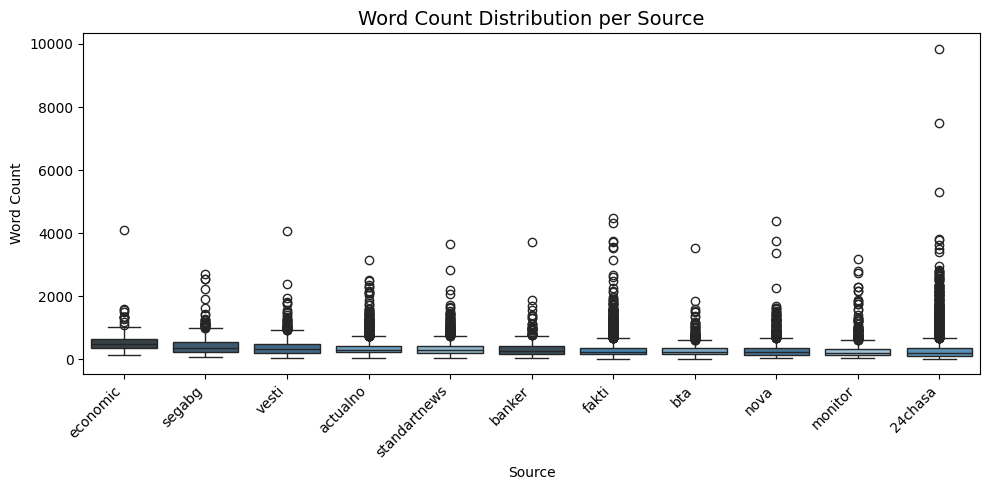

In [1861]:
fig, ax = plt.subplots(figsize=(10, 5))
sources_ordered = (
    df.groupby("source")["word_count"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df,
    x="source",
    y="word_count",
    order=sources_ordered,
    palette="Blues_d",
    ax=ax,
    hue="source",
    legend=False,
)
ax.set_title("Word Count Distribution per Source", fontsize=14)
ax.set_xlabel("Source")
ax.set_ylabel("Word Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [1862]:
for source, threshold in [("24chasa", 3000), ("fakti", 2000)]:
    outliers = df[
        (df["source"] == source) & (df["word_count"] > threshold)
    ].sort_values("word_count", ascending=False)
    print(f"=== {source} > {threshold} words: {len(outliers)} ===")
    for _, row in outliers.head(5).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  URL: {row['url']}")
        print_by_words(row["full_text"])
        print()

=== 24chasa > 3000 words: 8 ===
  [9844 words] Вижте какво реши служебното правителство днес
  URL: https://www.24chasa.bg/bulgaria/article/22755990
Правителството прие Доклад за състоянието на администрацията през 2025 г. Министерският съвет прие Решение за приемане на Доклад за състоянието
на администрацията през 2025 г. Ежегодно, в изпълнение на Закона за администрацията, по предложение на министър- председателя, Министерският съвет приема
Доклад за състоянието на администрацията. Докладът за състоянието на администрацията през 2025 г. е изготвен на базата на информацията, попълвана
от администрациите в Интегрираната информационна система на държавната администрация, като е използвана информация и от други източници - Порталът за
електронното управление, Системата за управление на електронни форми (еФорми), Системата за автоматично попълване на електронни форми, Информационната система за съхранение
на изходен код, Платформата за достъп до обществена информация и др. Докладът за със

There are still outliers for words distribution, but they are valid texts, so all good 

In [1863]:
len(df)

23351